In [ ]:
import marimo as mo

> **Generated file.** This notebook is exported from its marimo source
> `src/pipelines/02_fnd_eda_notebooks/04_eco_eda.py`.
> Edit the source and re-export; do not edit the exported notebook by hand.

# 04 - ECO: six Zurich flats under the microscope

**What this notebook is.** An analyst's walk through the ECO dataset
(Beckel, Kleiminger, Cicchetti, Staake & Santini, *e-Energy* 2014; ETH Zurich)
as staged in our fnd layer: six Swiss flats recorded from June 2012 into
January 2013, each with a three-phase smart meter at 1 Hz, a fleet of 1 Hz
plug-level smart sockets, and - for five of the six flats - 1 Hz occupancy
labels. ECO is the only dataset in our suite where appliance labels, the
panel and a ground-truth "someone is home" signal all tick at the same second.

**Who this is for.** Someone who has not seen ECO before and needs a working
mental model: what was collected, how the meters behave, where the traps are,
and what the data can and cannot supervise in a NILM stack.

**How to read it.** Every number printed in prose is computed by the notebook
from the staged Parquet files (scratch exploration only informed *which*
windows to show). Tags: **[collectable]** marks a finding or practice we could
reproduce in a Shelly-based deployment; **[insight only]** marks context that
shapes the problem but is not collectable.

**The route.** First we inventory the fleet (Q1), then we spend one day inside
flat 1 to see what the data feels like, and only then do we interrogate it:
whose clock does it run on (Q2), what does the panel really measure (Q3), why
house 1's watts land on a 10 W staircase for its first month (Q4), whether the
label board matches the physics (Q5), what the appliance signatures look like
(Q6), what the occupancy layer adds (Q7), and who actually pays the bill - how
much of the panel a plug-sum can explain (Q8).

In [ ]:
import os

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt

import eda_fnd_lib as eda

eda.apply_style()

<module 'matplotlib.pyplot' from '/root/longvdh/agent_space/projects/watt-wiser/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

## TL;DR

- **Six flats, one winter, all at exactly 1 Hz.** Five houses carry a full
17-column smart-meter series; house 4's panel file is empty (plug meters and
occupancy only); house 6 has no occupancy labels.

- **The clock is naive local wall clock (Swiss CET/CEST)** - the DST fall-back
day has exactly 86,400 rows because the repeated hour was stitched out, and
the evening load peak sits at 20:00-22:00 on the naive stamps. Never add a
UTC offset (Q2).

- **Coverage is the anti-REDD**: house 1 runs 245 days without a single gap;
the other four panel series each have exactly one contiguous outage - and
house 3's plugs kept recording straight through its 52-day panel outage (Q1, Q8).

- **House 1's panel is 10 W-quantised for its first 28.5 days**, then switches
to sub-watt resolution mid-stream; the release doc rounds this to "the first
29 days", the data pins the exact second (Q4).

- **The panel's additivity is exact** (powerallphases = sum of the three phase
powers), but the per-phase V, I, phase-angle columns only approximately
reconstruct power, and house 2's neutral-current channel is a dead all-zero
channel (Q3).

- **Labels are physics you can argue with**: three kettles behave like
textbooks, one draws 2.1 kW plateaus for up to 20 minutes (stuck thermostat?),
one "kettle" idles at 9 W - and house 2's "Entertainment" plug is *defined* as
its TV + stereo plugs, so naive plug-sums double-count (Q5, Q8).

- **The plug meters see a minority of the load almost everywhere** - from
roughly a third of house 1's energy down to a few percent in house 3 - so ECO
supervises appliance signatures well but whole-home attribution poorly (Q8).

- **Occupancy labels are a second supervision layer** with their own quirks:
two windows per house (except house 6), and vacant hours still draw a real
always-on base (Q7).

## Q1 - What was collected, and in what shape?

*Question: how many houses, meters and samples are here, over what dates, at
what cadence, and with what holes?*

The fnd layer stores ECO as one Parquet per house: `sm.parquet` (the smart
meter: 17 columns - three-phase voltage, current, power, phase angles and a
neutral current), one `plug_XX.parquet` per appliance socket (a single
`consumption` column, watts), and `occupancy_{summer,winter}.parquet`
where present. The gold map (`data/gold/appliance_map_eco.json`) carries
per-plug labels. The table below is the whole fleet in one look.

In [ ]:
AMAP = eda.appliance_map("eco")
SCANS = {}
SM_GAPS = {}
OCC_FILES = {}
N_PLUGS = 0
for h in range(1, 7):
    hdir = eda.fnd_file("eco", "house_%02d" % h)
    sm_p = os.path.join(hdir, "sm.parquet")
    n_sm = pq.ParquetFile(sm_p).metadata.num_rows
    gaps = []
    scan = None
    if n_sm:
        t_ts = pq.read_table(sm_p, columns=["ts_us"])
        ts_all = np.asarray(t_ts["ts_us"], dtype=np.int64)
        del t_ts
        dt_s = np.diff(ts_all) / 1e6
        gap_idx = np.flatnonzero(dt_s > 2.0)
        if len(gap_idx):
            brk = np.flatnonzero(np.diff(gap_idx) > 1)
            seg_starts = np.concatenate([[0], brk + 1])
            seg_ends = np.concatenate([brk, [len(gap_idx) - 1]])
            for s_i, e_i in zip(seg_starts, seg_ends):
                i0 = int(gap_idx[s_i])
                i1 = int(gap_idx[e_i])
                gaps.append((int(ts_all[i0]), float(dt_s[i0:i1 + 1].sum())))
            del brk, seg_starts, seg_ends
        del ts_all, dt_s, gap_idx
        scan = eda.scan_power_series(sm_p, value_col="powerallphases", missing_values=(-1.0,))
    SCANS[h] = scan
    SM_GAPS[h] = gaps
    plug_files = sorted(f for f in os.listdir(hdir) if f.startswith("plug_") and f.endswith(".parquet"))
    occ = [w for w in ("summer", "winter") if os.path.exists(os.path.join(hdir, "occupancy_%s.parquet" % w))]
    OCC_FILES[h] = occ
    N_PLUGS += len(plug_files)
_rows = []
for h in range(1, 7):
    scan = SCANS[h]
    gaps = SM_GAPS[h]
    nplugs = len([f for f in os.listdir(eda.fnd_file("eco", "house_%02d" % h))
                  if f.startswith("plug_") and f.endswith(".parquet")])
    occ = OCC_FILES[h]
    if scan is None:
        _rows.append((h, "0 (empty file)", "-", "-", "-", "-", nplugs,
                      ", ".join(occ) if occ else "none"))
    else:
        gap_txt = "; ".join(
            "%.1f d from %s" % (g / 86400.0, pd.Timestamp(t, unit="us").strftime("%Y-%m-%d"))
            for t, g in gaps) or "none"
        _rows.append((h, eda.fmt_int(scan["n"]), "%.0f" % scan["span_days"],
                      "%.0f" % scan["mean_w"], "%.0f" % scan["energy_kwh"],
                      gap_txt, nplugs, ", ".join(occ) if occ else "none"))
INV_TBL = mo.md(eda.md_table(
    ["house", "panel rows", "span d", "mean W", "panel kWh", "panel outage(s)", "plugs", "occupancy files"],
    _rows))
INV_TBL

| house | panel rows | span d | mean W | panel kWh | panel outage(s) | plugs | occupancy files |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | 21,168,000 | 245 | 283 | 1658 | none | 7 | summer, winter |
| 2 | 21,081,600 | 245 | 213 | 1232 | 1.0 d from 2012-11-27 | 12 | summer, winter |
| 3 | 11,923,200 | 190 | 361 | 1182 | 52.0 d from 2012-10-14 | 7 | summer, winter |
| 4 | 0 (empty file) | - | - | - | - | 8 | summer, winter |
| 5 | 18,576,000 | 219 | 797 | 4075 | 4.0 d from 2012-09-06 | 8 | summer, winter |
| 6 | 14,342,400 | 219 | 208 | 825 | 53.0 d from 2012-11-11 | 7 | none |

In [ ]:
_h1 = SCANS[1]
_h5 = SCANS[5]
_gap3 = SM_GAPS[3][0][1] / 86400.0
_gap6 = SM_GAPS[6][0][1] / 86400.0
mo.md(f"""
**Reading it.** Five lived-in flats and one spectre. House 4 is the archaeology
exhibit: its panel file exists but holds **zero rows** - the flat is known only
through its 8 plug meters and unusually dense occupancy labels. The other five
panels could not be more different as households: house 1 idles along at
**{_h1["mean_w"]:.0f} W** on average while house 5 burns
**{_h5["mean_w"]:.0f} W** - over {_h5["energy_kwh"]:.0f} kWh in seven months,
more than twice any other flat in the study.

The outage column is its own story. House 1 is **gapless for
{_h1["span_days"]:.0f} days** - 21 million seconds, every single one present.
Houses 2 and 5 each dropped a few days; house 3 lost **{_gap3:.0f} days** from
mid-October and house 6 **{_gap6:.0f} days** from mid-November. In total
**{N_PLUGS} plug meters** ride along - and, as Q8 will show, house 3's plugs
never stopped during its panel outage, which makes that a *panel* outage, not
a household one.
""")

**Reading it.** Five lived-in flats and one spectre. House 4 is the archaeology
exhibit: its panel file exists but holds **zero rows** - the flat is known only
through its 8 plug meters and unusually dense occupancy labels. The other five
panels could not be more different as households: house 1 idles along at
**283 W** on average while house 5 burns
**797 W** - over 4075 kWh in seven months,
more than twice any other flat in the study.

The outage column is its own story. House 1 is **gapless for
245 days** - 21 million seconds, every single one present.
Houses 2 and 5 each dropped a few days; house 3 lost **52 days** from
mid-October and house 6 **53 days** from mid-November. In total
**49 plug meters** ride along - and, as Q8 will show, house 3's plugs
never stopped during its panel outage, which makes that a *panel* outage, not
a household one.

## A day in the life - Friday, 30 November 2012, flat 1

Before any statistics: what does one day of this data actually feel like?
We picked a Friday late in the study, when house 1 was fully instrumented,
and laid the panel (1-minute means) over the five plug meters that were alive
that day. Everything in the next three cells is that one figure, read slowly.

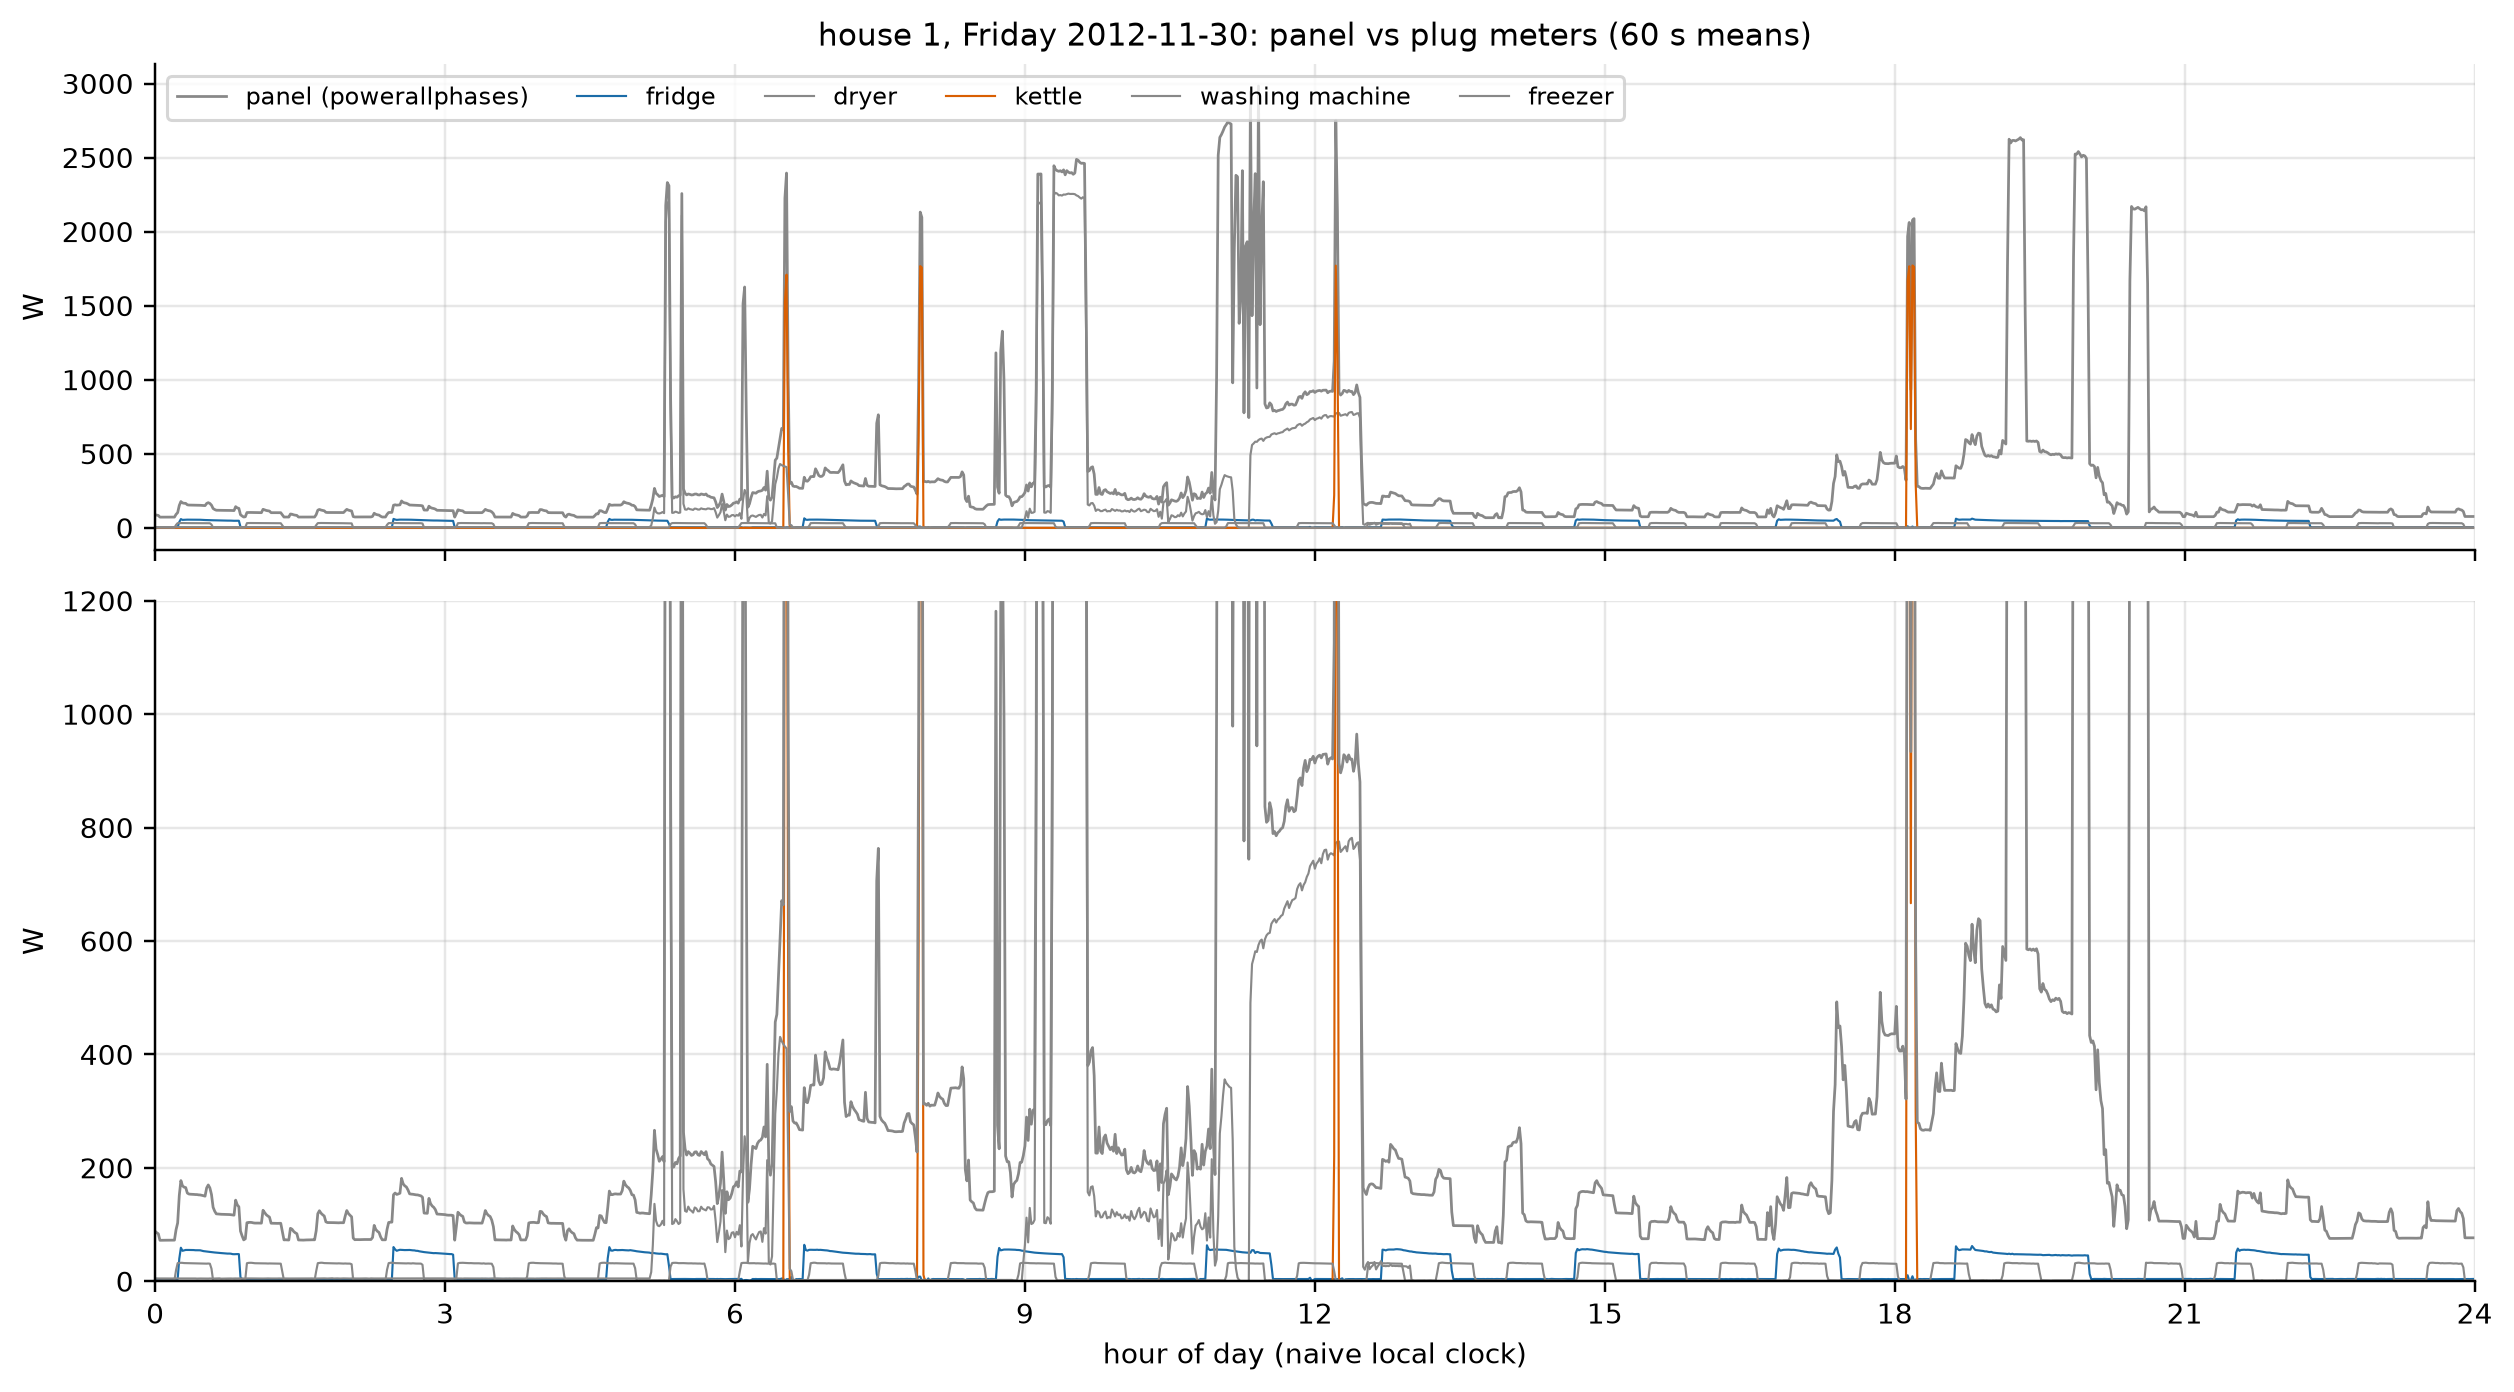

In [ ]:
# house 1 panel, full span - kept for the clock / staircase forensics below
_t1 = pq.read_table(eda.fnd_file("eco", "house_01", "sm.parquet"), columns=["ts_us", "powerallphases"])
ts1 = np.asarray(_t1["ts_us"], dtype=np.int64)
v1 = np.asarray(_t1["powerallphases"], dtype=np.float64)
del _t1

hero_day = "2012-11-30"
hero_a = int(pd.Timestamp(hero_day).value // 1000)
hero_n = 1440
_dm = (ts1 >= hero_a) & (ts1 < hero_a + 86_400_000_000)
_, p60 = eda.resample_grid(ts1[_dm], v1[_dm], 60, hero_a, hero_n)
del _dm

overlay = {}
k_ts = None
k_v = None
wash_zoom = None
fridge_day = None
freezer_day = None
_wash_ts = _wash_v = None
for _plug, _lab in ((1, "fridge"), (2, "dryer"), (4, "kettle"), (5, "washing machine"), (7, "freezer")):
    _t_p, _v_p = eda.read_channel(eda.fnd_file("eco", "house_01", "plug_%02d.parquet" % _plug),
                                  value_col="consumption")
    _m = (_t_p >= hero_a) & (_t_p < hero_a + 86_400_000_000)
    _, overlay[_lab] = eda.resample_grid(_t_p[_m], _v_p[_m], 60, hero_a, hero_n)
    if _plug == 4:
        k_ts, k_v = _t_p, _v_p
    elif _plug == 5:
        _zm = (_t_p >= hero_a + 8 * 3_600_000_000) & (_t_p < hero_a + 14 * 3_600_000_000)
        wash_zoom = (_t_p[_zm].copy(), _v_p[_zm].copy())
        _wash_ts, _wash_v = _t_p, _v_p
    elif _plug == 1:
        fridge_day = (_t_p[_m].copy(), _v_p[_m].copy())
        del _t_p, _v_p
    elif _plug == 7:
        freezer_day = (_t_p[_m].copy(), _v_p[_m].copy())
        del _t_p, _v_p
    else:
        del _t_p, _v_p

def _day_kwh(y):
    return float(np.nansum(y) * 60.0 / 3.6e6)

hero_panel_kwh = _day_kwh(p60)
hero_plug_kwh = float(sum(_day_kwh(y) for y in overlay.values()))
hero_share = 100.0 * hero_plug_kwh / hero_panel_kwh

# un-metered evening block 19:00-21:30 (panel minus plug-sum)
_ev = slice(19 * 60, 21 * 60 + 30)
_plug_ev = np.nansum(np.vstack([overlay[_k][_ev] for _k in overlay]), axis=0)
ev_panel_w = float(np.nanmean(p60[_ev]))
ev_resid_w = ev_panel_w - float(np.nanmean(_plug_ev))
del _plug_ev

# washer: program blocks over the full span (above 100 W for >= 15 min)
_onw = (_wash_v > 100.0).astype(np.int8)
_dw = np.diff(np.concatenate([[0], _onw, [0]]))
_ws, _we = np.flatnonzero(_dw == 1), np.flatnonzero(_dw == -1)
_keep = (_we - _ws) >= 900
wash_blocks_n = int(_keep.sum())
wash_dwell_med = float(np.median((_wash_ts[_we[_keep] - 1] - _wash_ts[_ws[_keep]]) / 60e6))
# the hero day's program: first block of the day
_onz = (wash_zoom[1] > 100.0).astype(np.int8)
_dz = np.diff(np.concatenate([[0], _onz, [0]]))
_zs, _ze = np.flatnonzero(_dz == 1), np.flatnonzero(_dz == -1)
_kz = (_ze - _zs) >= 900
_zs, _ze = _zs[_kz], _ze[_kz]
wash_start_txt = pd.Timestamp(wash_zoom[0][_zs[0]], unit="us").strftime("%H:%M")
wash_dur_min = float(wash_zoom[0][_ze[0] - 1] - wash_zoom[0][_zs[0]]) / 60e6
wash_peak_w = float(wash_zoom[1][_zs[0]:_ze[0]].max())
del _onz, _dz, _zs, _ze, _kz, _wash_ts, _wash_v, _onw, _dw, _ws, _we, _keep

# kettle boils over the full kettle span (> 1500 W draws, gaps <= 30 s merged)
_runs = []
_onb = (k_v > 1500.0).astype(np.int8)
_db = np.diff(np.concatenate([[0], _onb, [0]]))
_bs, _be = np.flatnonzero(_db == 1), np.flatnonzero(_db == -1)
_kb = (_be - _bs) >= 20
_bs, _be = _bs[_kb], _be[_kb]
if len(_bs):
    _cs, _ce = int(_bs[0]), int(_be[0])
    for _s, _e in zip(_bs[1:], _be[1:]):
        if int(_s) - _ce <= 30:
            _ce = int(_e)
        else:
            _runs.append((_cs, _ce))
            _cs, _ce = int(_s), int(_e)
    _runs.append((_cs, _ce))
boil_n = len(_runs)
boil_dur_med = float(np.median([e - s for s, e in _runs]))
boil_peak_p50 = float(np.median([k_v[s:e].max() for s, e in _runs]))
kettle_span_d = float(k_ts[-1] - k_ts[0]) / 86_400e6
boil_eps_day = boil_n / kettle_span_d
boil_max_dur_s = float(max(e - s for s, e in _runs))
_hday = [(s, e) for s, e in _runs if hero_a <= k_ts[s] < hero_a + 86_400_000_000]
boil_n_day = len(_hday)
boil_spree_n = int(sum(1 for s, e in _hday
                       if hero_a + 10 * 3_600_000_000 <= k_ts[s] < hero_a + 11 * 3_600_000_000 + 20 * 60_000_000))
boil_kday_max = int(np.max(np.bincount((k_ts[[s for s, e in _runs]] // 86_400_000_000).astype(np.int64))))
boil_times_txt = ", ".join(pd.Timestamp(int(k_ts[s]), unit="us").strftime("%H:%M")
                           for s, e in _hday)
del _onb, _db, _bs, _be, _kb, _runs, _hday

# ---- the hero-day figure -------------------------------------------------
_fig, (_axA, _axB) = plt.subplots(2, 1, figsize=(11.5, 6.4), sharex=True,
                                  gridspec_kw={"height_ratios": [1.0, 1.4]})
_x = np.arange(hero_n) / 60.0
_axA.plot(_x, p60, lw=0.9, color=eda.canon_color("mains"), label="panel (powerallphases)")
for _lab, _y in overlay.items():
    _axA.plot(_x, _y, lw=0.7, color=eda.canon_color(_lab), label=_lab)
_axA.set_ylabel("W")
_axA.set_title("house 1, Friday 2012-11-30: panel vs plug meters (60 s means)")
_axA.legend(loc="upper left", ncol=6, fontsize=8)
for _lab, _y in overlay.items():
    _axB.plot(_x, _y, lw=0.7, color=eda.canon_color(_lab), label=_lab)
_axB.plot(_x, p60, lw=0.9, color=eda.canon_color("mains"), label="panel")
_axB.set_ylim(0, 1200)
_axB.set_xlim(0, 24)
_axB.set_xticks(range(0, 25, 3))
_axB.set_xlabel("hour of day (naive local clock)")
_axB.set_ylabel("W")
_fig.tight_layout()
_fig  # render figure as cell output

In [ ]:
mo.md(f"""
**Reading it.** The day has a shape you can narrate hour by hour. Overnight the
flat sleeps at a steady base; the only heartbeat is the fridge-freezer pair -
in the lower panel you can see the two compressors trading duty cycles all
night (fridge and freezer sawtoothing between tens and two hundred
watts). At **{wash_start_txt}** the washing machine starts a real program:
**{wash_dur_min:.0f} minutes**, peaking at **{wash_peak_w:.0f} W** - that
plateau is the heater, and it is exactly the shape a disaggregation model
should learn.

Mid-morning belongs to the kettle: **{boil_n_day} boils** this day, at
{boil_times_txt} - breakfast teas, one just before lunch, and a
back-to-back evening pair. Lunch leaves a trace the plugs *cannot* explain: between 12:20 and
13:10 the panel runs a repeating ~2 kW sawtooth (cooking on an un-instrumented
stove) that shows up as pure residual. The afternoon is quiet until the dryer
ramps through 12:50-13:30, and then the evening does the strangest thing of
all: from 19:00 to 21:30 the panel averages **{ev_panel_w:.0f} W** while the
five plugs together average less than a tenth of that - a residual of
**{ev_resid_w:.0f} W** of cooking, lights and electronics that no socket saw.

That is the day's energy ledger in one line: the panel recorded
**{hero_panel_kwh:.1f} kWh**, the five plugs together
**{hero_plug_kwh:.1f} kWh** - the labels explain only
**{hero_share:.0f}%** of this particular day. Remember that number when we
reach Q8.
""")

**Reading it.** The day has a shape you can narrate hour by hour. Overnight the
flat sleeps at a steady base; the only heartbeat is the fridge-freezer pair -
in the lower panel you can see the two compressors trading duty cycles all
night (fridge and freezer sawtoothing between tens and two hundred
watts). At **09:17** the washing machine starts a real program:
**21 minutes**, peaking at **2328 W** - that
plateau is the heater, and it is exactly the shape a disaggregation model
should learn.

Mid-morning belongs to the kettle: **5 boils** this day, at
06:31, 07:54, 12:12, 18:08, 18:10 - breakfast teas, one just before lunch, and a
back-to-back evening pair. Lunch leaves a trace the plugs *cannot* explain: between 12:20 and
13:10 the panel runs a repeating ~2 kW sawtooth (cooking on an un-instrumented
stove) that shows up as pure residual. The afternoon is quiet until the dryer
ramps through 12:50-13:30, and then the evening does the strangest thing of
all: from 19:00 to 21:30 the panel averages **728 W** while the
five plugs together average less than a tenth of that - a residual of
**689 W** of cooking, lights and electronics that no socket saw.

That is the day's energy ledger in one line: the panel recorded
**8.8 kWh**, the five plugs together
**3.6 kWh** - the labels explain only
**40%** of this particular day. Remember that number when we
reach Q8.

### The kettle, up close - the dataset's metronome

The kettle is ECO's most reliable teacher: a clean, unambiguous 1.8 kW
trapezoid at 1 s resolution, several times a day, in every house. Here is the
first boil of that Friday at full resolution.

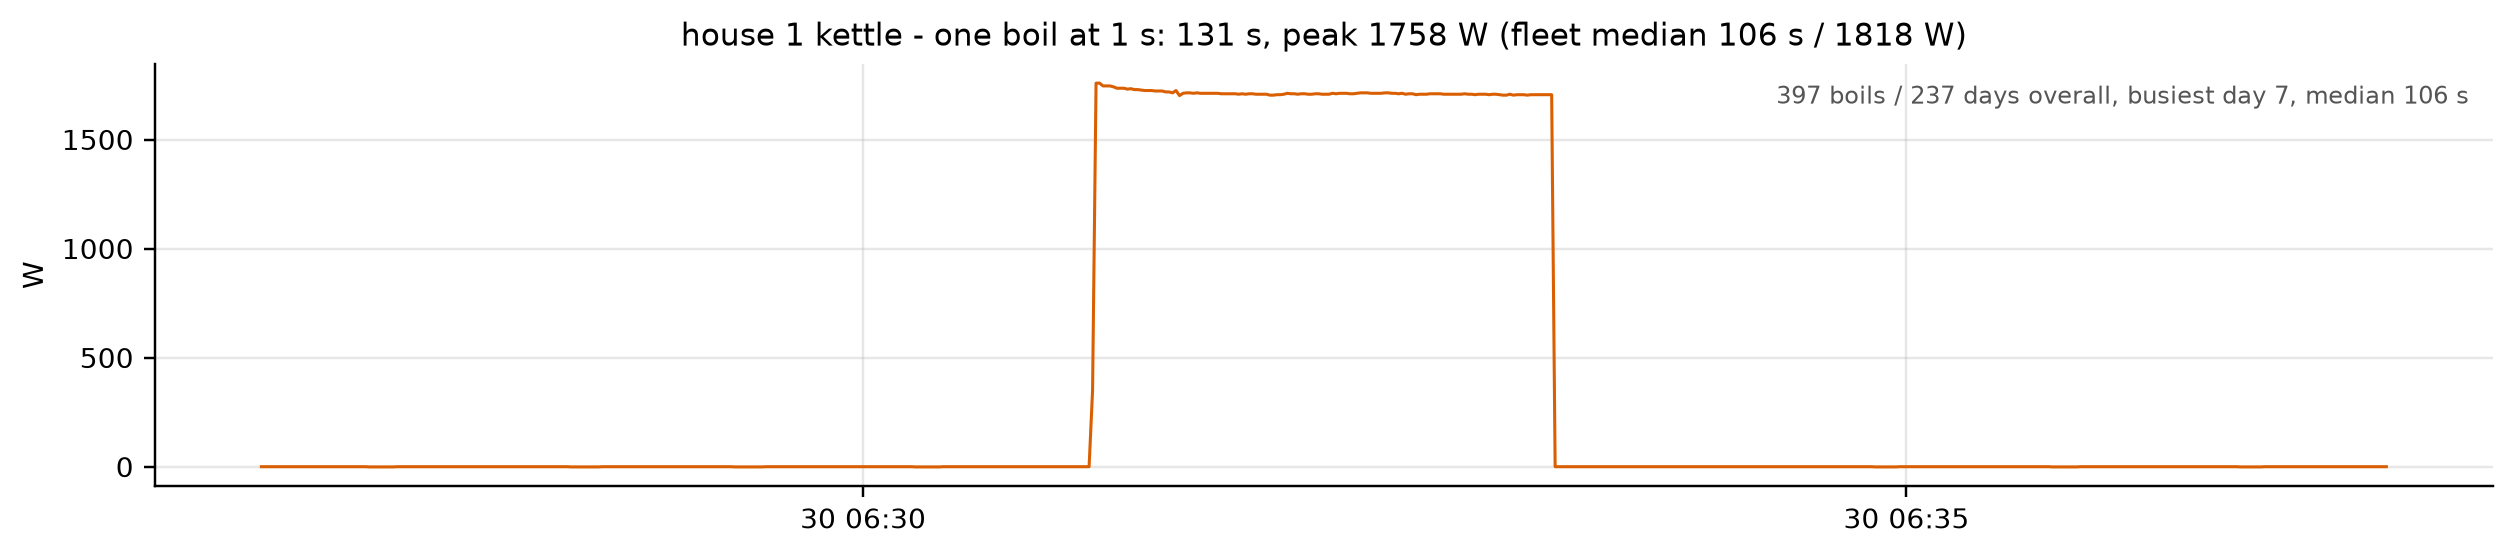

In [ ]:
# first boil of the hero day, +/- 4 minutes, raw 1 s
_day_m = (k_ts >= hero_a) & (k_ts < hero_a + 86_400_000_000)
_day_v = k_v[_day_m]
_day_t = k_ts[_day_m]
_on = (_day_v > 1500.0).astype(np.int8)
_d = np.diff(np.concatenate([[0], _on, [0]]))
_s, _e = np.flatnonzero(_d == 1), np.flatnonzero(_d == -1)
_keep = (_e - _s) >= 30
_s, _e = _s[_keep], _e[_keep]
_t0 = int(_day_t[_s[0]])
_t1 = int(_day_t[_e[0] - 1])
_m = (k_ts >= _t0 - 4 * 60_000_000) & (k_ts <= _t1 + 4 * 60_000_000)
_peak = float(k_v[_m].max())
_dur = (_t1 - _t0) / 1e6
_fig, _ax = plt.subplots(figsize=(11.5, 2.6))
_ax.plot(pd.to_datetime(k_ts[_m], unit="us"), k_v[_m], lw=1.0,
         color=eda.canon_color("kettle"))
_ax.set_ylabel("W")
_ax.set_title(
    "house 1 kettle - one boil at 1 s: %.0f s, peak %.0f W (fleet median %.0f s / %.0f W)"
    % (_dur, _peak, boil_dur_med, boil_peak_p50), fontsize=10)
_ax.text(0.99, 0.95,
         "%d boils / %d days overall, busiest day %d, median %.0f s"
         % (boil_n, int(round(k_ts[-1] / 86_400e6 - k_ts[0] / 86_400e6)), boil_kday_max, boil_dur_med),
         transform=_ax.transAxes, ha="right", va="top", fontsize=8, color="#555555")
_fig.tight_layout()
_fig  # render figure as cell output

In [ ]:
mo.md(f"""
**Reading it.** One kettle, one second, no ambiguity: the element switches,
the water crosses the boil, the element switches off - about
**{boil_dur_med:.0f} seconds** wall to wall at the median, peaking near
**{boil_peak_p50:.0f} W**. Across the whole span the plug caught
**{boil_n} boils** ({boil_eps_day:.1f}/day, busiest day
{boil_kday_max}), the longest single draw lasting
{boil_max_dur_s / 60.0:.0f} minutes. This is the cleanest event label in the
dataset - and in Q5 we will see that the other houses' "kettles" are *not*
all this kettle. **[collectable]** A Shelly plug on the kettle gives the same
signal; there is no cheaper ground truth for event-based evaluation.
""")

**Reading it.** One kettle, one second, no ambiguity: the element switches,
the water crosses the boil, the element switches off - about
**106 seconds** wall to wall at the median, peaking near
**1818 W**. Across the whole span the plug caught
**397 boils** (1.7/day, busiest day
7), the longest single draw lasting
7 minutes. This is the cleanest event label in the
dataset - and in Q5 we will see that the other houses' "kettles" are *not*
all this kettle. **[collectable]** A Shelly plug on the kettle gives the same
signal; there is no cheaper ground truth for event-based evaluation.

## Q2 - Whose clock does the dataset run on? [insight only]

*Question: are the timestamps UTC or local time - and does it matter?*

The naive-stamp question is not pedantry: every downstream join, every
"morning peak", every train/test split by date depends on it. ECO gives us
three independent pieces of evidence, all computed below: the row counts on
the DST fall-back weekend, the release doc's own wording, and the diurnal
shape of load.

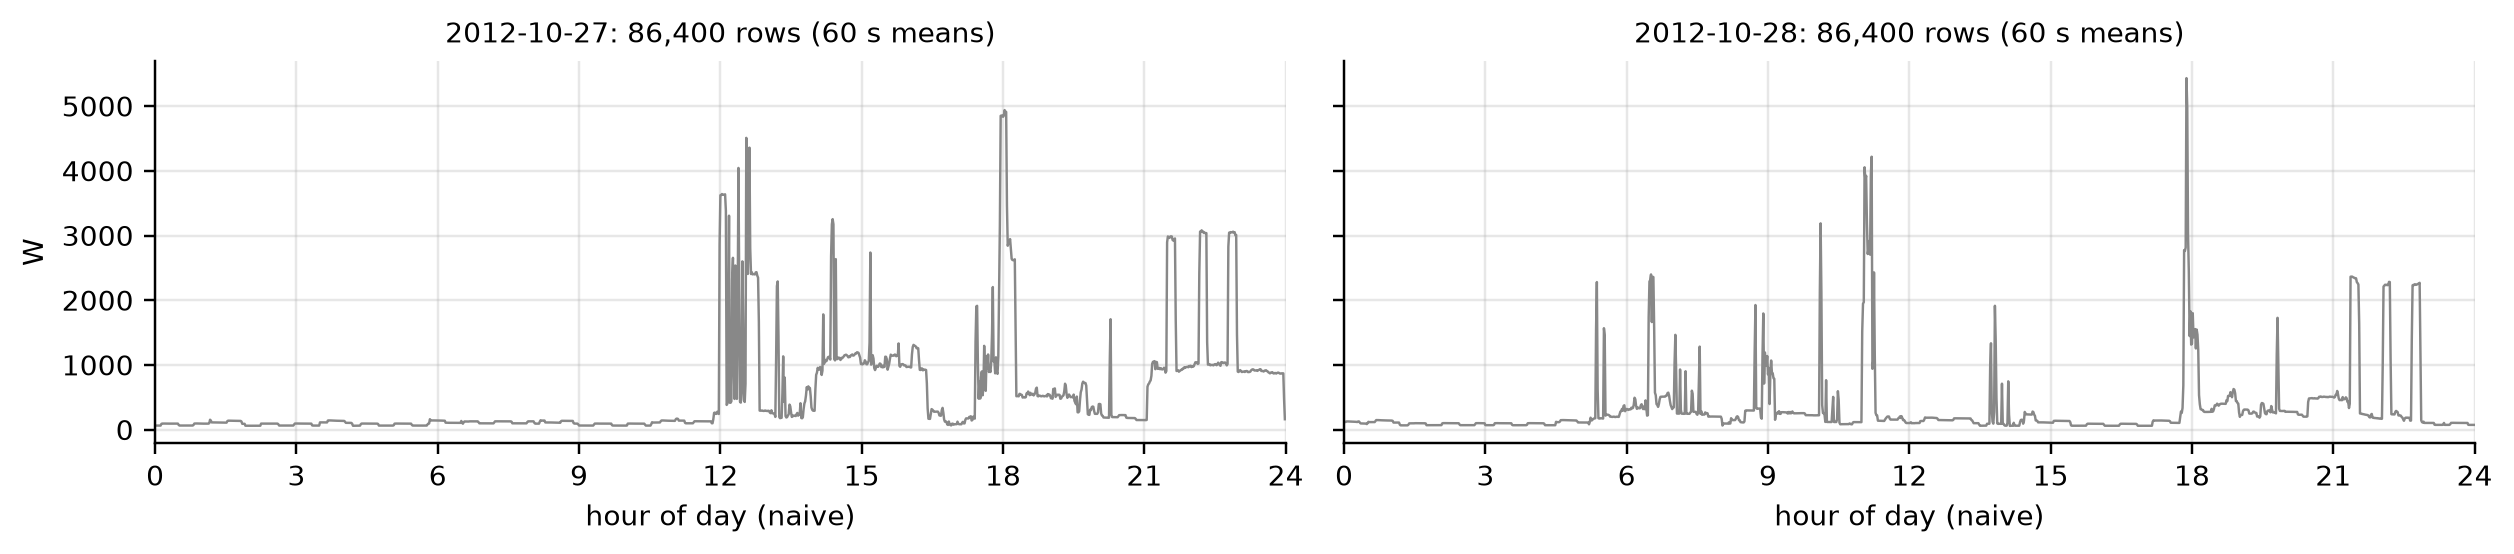

In [ ]:
# row counts on the DST fall-back weekend + both days plotted
DST_ROWS = {}
_fig, _axes = plt.subplots(1, 2, figsize=(11.5, 2.6), sharey=True)
for _ax, _day in zip(_axes, ("2012-10-27", "2012-10-28")):
    _a = int(pd.Timestamp(_day).value // 1000)
    _m = (ts1 >= _a) & (ts1 < _a + 86_400_000_000)
    DST_ROWS[_day] = int(_m.sum())
    _, _y = eda.resample_grid(ts1[_m], v1[_m], 60, _a, 1440)
    _ax.plot(np.arange(1440) / 60.0, _y, lw=0.8, color=eda.canon_color("mains"))
    _ax.set_title("%s: %s rows (60 s means)" % (_day, eda.fmt_int(DST_ROWS[_day])), fontsize=9)
    _ax.set_xlabel("hour of day (naive)")
    _ax.set_xlim(0, 24)
    _ax.set_xticks(range(0, 25, 3))
_axes[0].set_ylabel("W")
_fig.tight_layout()
_fig  # render figure as cell output

In [ ]:
# per-house diurnal profile facts from the Q1 scans
PEAKS = {}
for _h in range(1, 7):
    if SCANS[_h] is not None:
        _d = SCANS[_h]["diurnal"]
        PEAKS[_h] = (int(np.argmax(_d)), float(np.max(_d)), float(_d[3]))
_pk_rows = [(_h, "%02d:00" % PEAKS[_h][0], "%.0f" % PEAKS[_h][1], "%.0f" % PEAKS[_h][2])
            for _h in sorted(PEAKS)]
PEAKS_TBL = eda.md_table(["house", "peak hour (naive)", "peak mean W", "03:00 W"], _pk_rows)

In [ ]:
mo.md(f"""
**Reading it.** The release doc states it outright: *"the measurements are
stored ... the day files are named after the local date"* - Swiss local time,
CET/CEST. The data agrees three ways. First, the DST fall-back weekend: both
2012-10-27 and the fall-back day 2012-10-28 hold exactly
**{DST_ROWS["2012-10-28"]:,} rows** - a UTC-anchored 1 Hz grid would need
90,000 rows on the repeated day, and there is no trace of a 25-hour day or a
repeated hour anywhere in the panel (house 1's dt is exactly 1 s at every
step). Second, the diurnal peak of every house lands at
**20:00-23:00 on the naive stamps** - shift by +1 h and every household
would cook dinner at midnight UTC. Third, the fall-back day's curve is flat
and ordinary: the release simply stitched the repeated wall-clock hour out.

So: **naive local wall clock, by construction** - the same convention as our
own Shelly logs and the same trap as REDD (notebook 02's Q2). The practical
rules: never add an offset; treat "hour of day" as Swiss local time; and
expect two 86,400-row days per year to be *relabelled*, not duplicated.

| house | peak hour (naive) | peak W | 03:00 W |
|---|---|---|---|
{PEAKS_TBL.splitlines()[2]}
{PEAKS_TBL.splitlines()[3]}
{PEAKS_TBL.splitlines()[4]}
{PEAKS_TBL.splitlines()[5]}
{PEAKS_TBL.splitlines()[6]}
""")

**Reading it.** The release doc states it outright: *"the measurements are
stored ... the day files are named after the local date"* - Swiss local time,
CET/CEST. The data agrees three ways. First, the DST fall-back weekend: both
2012-10-27 and the fall-back day 2012-10-28 hold exactly
**86,400 rows** - a UTC-anchored 1 Hz grid would need
90,000 rows on the repeated day, and there is no trace of a 25-hour day or a
repeated hour anywhere in the panel (house 1's dt is exactly 1 s at every
step). Second, the diurnal peak of every house lands at
**20:00-23:00 on the naive stamps** - shift by +1 h and every household
would cook dinner at midnight UTC. Third, the fall-back day's curve is flat
and ordinary: the release simply stitched the repeated wall-clock hour out.

So: **naive local wall clock, by construction** - the same convention as our
own Shelly logs and the same trap as REDD (notebook 02's Q2). The practical
rules: never add an offset; treat "hour of day" as Swiss local time; and
expect two 86,400-row days per year to be *relabelled*, not duplicated.

| house | peak hour (naive) | peak W | 03:00 W |
|---|---|---|---|
| 1 | 22:00 | 560 | 103 |
| 2 | 20:00 | 392 | 90 |
| 3 | 22:00 | 3146 | 248 |
| 5 | 23:00 | 1861 | 458 |
| 6 | 07:00 | 290 | 139 |

## Q3 - What does the panel actually measure?

*Question: the smart meter logs 16 quantities at 1 Hz - which of them are
trustworthy, and what are the traps?*

Each `sm.parquet` carries `powerallphases`, per-phase powers
(`powerl1..3`), currents, voltages, five phase angles and a
`currentneutral`. Two identities should hold if the meter is coherent:
the powers must **add** (all = L1+L2+L3), and active power should reconstruct
from voltage, current and the phase angle (P = V·I·cos phi).

In [ ]:
import pyarrow.dataset as _ds

_day_a = int(pd.Timestamp("2012-09-15").value // 1000)
PHASE = {}
VI = {}
CN = {}
for _h in (1, 2, 5):
    _dset = _ds.dataset(eda.fnd_file("eco", "house_%02d" % _h, "sm.parquet"), format="parquet")
    _tab = _dset.to_table(filter=(_ds.field("ts_us") >= _day_a) & (_ds.field("ts_us") < _day_a + 86_400_000_000))
    _d = _tab.to_pydict()
    del _tab, _dset
    _pall = np.asarray(_d["powerallphases"], dtype=np.float64)
    _psum = (np.asarray(_d["powerl1"], dtype=np.float64)
             + np.asarray(_d["powerl2"], dtype=np.float64)
             + np.asarray(_d["powerl3"], dtype=np.float64))
    _r = _pall - _psum
    PHASE[_h] = (float(np.abs(_r).max()), float(np.abs(_r).mean()))
    _v1c = np.asarray(_d["voltagel1"], dtype=np.float64)
    _i1c = np.asarray(_d["currentl1"], dtype=np.float64)
    _ang = np.asarray(_d["phaseanglecurrentvoltagel1"], dtype=np.float64)
    _pid = np.abs(np.asarray(_d["powerl1"], dtype=np.float64)
                  - _v1c * _i1c * np.cos(np.radians(_ang)))
    VI[_h] = (float(_pid.mean()), float(np.percentile(_pid, 99)), float(_v1c.mean()))
    _cn = np.asarray(_d["currentneutral"], dtype=np.float64)
    CN[_h] = (float((_cn == 0).mean()), float((_cn == -1).mean()), float(_cn.mean()))
    del _d, _pall, _psum, _r, _v1c, _i1c, _ang, _pid, _cn

# per-house floor of the panel (min valid W and p1) over the full series
FLOORS = {}
for _h in (2, 3, 5, 6):
    _t_f = pq.read_table(eda.fnd_file("eco", "house_%02d" % _h, "sm.parquet"),
                         columns=["powerallphases"])
    _v_f = np.asarray(_t_f["powerallphases"], dtype=np.float64)
    del _t_f
    _ok = _v_f != -1.0
    FLOORS[_h] = (float(_v_f[_ok].min()), float(np.percentile(_v_f[_ok], 1)))
    del _v_f, _ok
_ok1 = v1 != -1.0
FLOORS[1] = (float(v1[_ok1].min()), float(np.percentile(v1[_ok1], 1)))
del _ok1

In [ ]:
_rows = []
for _h in (1, 2, 5):
    _cn_txt = ("all-zero channel" if CN[_h][0] > 0.99 else
               "real (mean %.2f A)" % CN[_h][2])
    _rows.append((_h, "%.2f" % PHASE[_h][0], "%.4f" % PHASE[_h][1],
                  "%.1f" % VI[_h][0], "%.0f" % VI[_h][1], _cn_txt))
_id_tbl = eda.md_table(
    ["house", "max|Pall-sum| W", "mean|Pall-sum| W", "mean|P1-V1I1cos| W",
     "p99 W", "currentneutral"], _rows)
_fl_rows = [(_h, "%.1f" % FLOORS[_h][0], "%.1f" % FLOORS[_h][1]) for _h in sorted(FLOORS)]
_fl_tbl = eda.md_table(["house", "min valid panel W", "p1 W"], _fl_rows)
mo.md(f"""
The identities, on one sample day (2012-09-15) per house:

{_id_tbl}

And the floor each panel never goes below, over its **full** series:

{_fl_tbl}
""")

The identities, on one sample day (2012-09-15) per house:

| house | max\|Pall-sum\| W | mean\|Pall-sum\| W | mean\|P1-V1I1cos\| W | p99 W | currentneutral |
| --- | --- | --- | --- | --- | --- |
| 1 | 0.01 | 0.0005 | 19.4 | 126 | real (mean 1.61 A) |
| 2 | 2.00 | 0.0007 | 3.4 | 10 | all-zero channel |
| 5 | 0.01 | 0.0001 | 3.8 | 5 | real (mean 1.52 A) |

And the floor each panel never goes below, over its **full** series:

| house | min valid panel W | p1 W |
| --- | --- | --- |
| 1 | 45.7 | 48.0 |
| 2 | -7.9 | 35.2 |
| 3 | 14.0 | 14.8 |
| 5 | 126.9 | 152.0 |
| 6 | 57.3 | 61.2 |

In [ ]:
mo.md(f"""
**Reading it.** The good news first: the **additivity identity is exact**.
`powerallphases` equals L1+L2+L3 to at most
**{PHASE[1][0]:.2f} W** in house 1 ({PHASE[2][0]:.2f} W in house 2,
{PHASE[5][0]:.2f} W in house 5), with means indistinguishable from zero - a
free ingestion check we should run on any three-phase feed.

The V-I-phase-angle route is a different animal: reconstructing L1 power as
V·I·cos phi leaves a mean residual of **{VI[1][0]:.0f} W** in house 1
(p99 {VI[1][1]:.0f} W) - the phase-angle columns are coarse, so never rebuild
power from them; take the power columns as primary. The neutral channel is a
coin flip across houses: house 1 records a real neutral current (mean
**{CN[1][2]:.2f} A**), while house 2's `currentneutral` is a
**dead channel** - {(100 * CN[2][0]):.2f}% exact zeros - with only
{100 * CN[2][1]:.3f}% sentinel -1s. Same meter firmware, one flat wired, one
not. **[collectable]** Per-channel sanity checks catch exactly this.

The floors table quietly contains the biggest household story in ECO: house 3
bottoms out at **{FLOORS[3][0]:.0f} W** and house 1 at **{FLOORS[1][0]:.0f} W**,
but house 5 never drops below **{FLOORS[5][0]:.0f} W** - its *quietest second*
is busier than house 1's median. That is electric heating (Q8), and it means
the "always-on base" differs by an order of magnitude across flats.
House 2's floor dips slightly negative (**{FLOORS[2][0]:.1f} W**) - a
handful of CT-noise samples, worth excluding with a `>= 0` clip, nothing more.
""")

**Reading it.** The good news first: the **additivity identity is exact**.
`powerallphases` equals L1+L2+L3 to at most
**0.01 W** in house 1 (2.00 W in house 2,
0.01 W in house 5), with means indistinguishable from zero - a
free ingestion check we should run on any three-phase feed.

The V-I-phase-angle route is a different animal: reconstructing L1 power as
V·I·cos phi leaves a mean residual of **19 W** in house 1
(p99 126 W) - the phase-angle columns are coarse, so never rebuild
power from them; take the power columns as primary. The neutral channel is a
coin flip across houses: house 1 records a real neutral current (mean
**1.61 A**), while house 2's `currentneutral` is a
**dead channel** - 99.97% exact zeros - with only
0.027% sentinel -1s. Same meter firmware, one flat wired, one
not. **[collectable]** Per-channel sanity checks catch exactly this.

The floors table quietly contains the biggest household story in ECO: house 3
bottoms out at **14 W** and house 1 at **46 W**,
but house 5 never drops below **127 W** - its *quietest second*
is busier than house 1's median. That is electric heating (Q8), and it means
the "always-on base" differs by an order of magnitude across flats.
House 2's floor dips slightly negative (**-7.9 W**) - a
handful of CT-noise samples, worth excluding with a `>= 0` clip, nothing more.

## Q4 - Why do house 1's watts land on a 10 W staircase?

*Question: the flagship house's panel looks coarse for its first month -
how coarse, where does it end, and what does it break?*

The release doc says the first "29 days" of every measurement were rounded to
10 W precision. Doc claims are where analysts go to check - let's find the
exact boundary in the data and see what each regime does to thresholds.

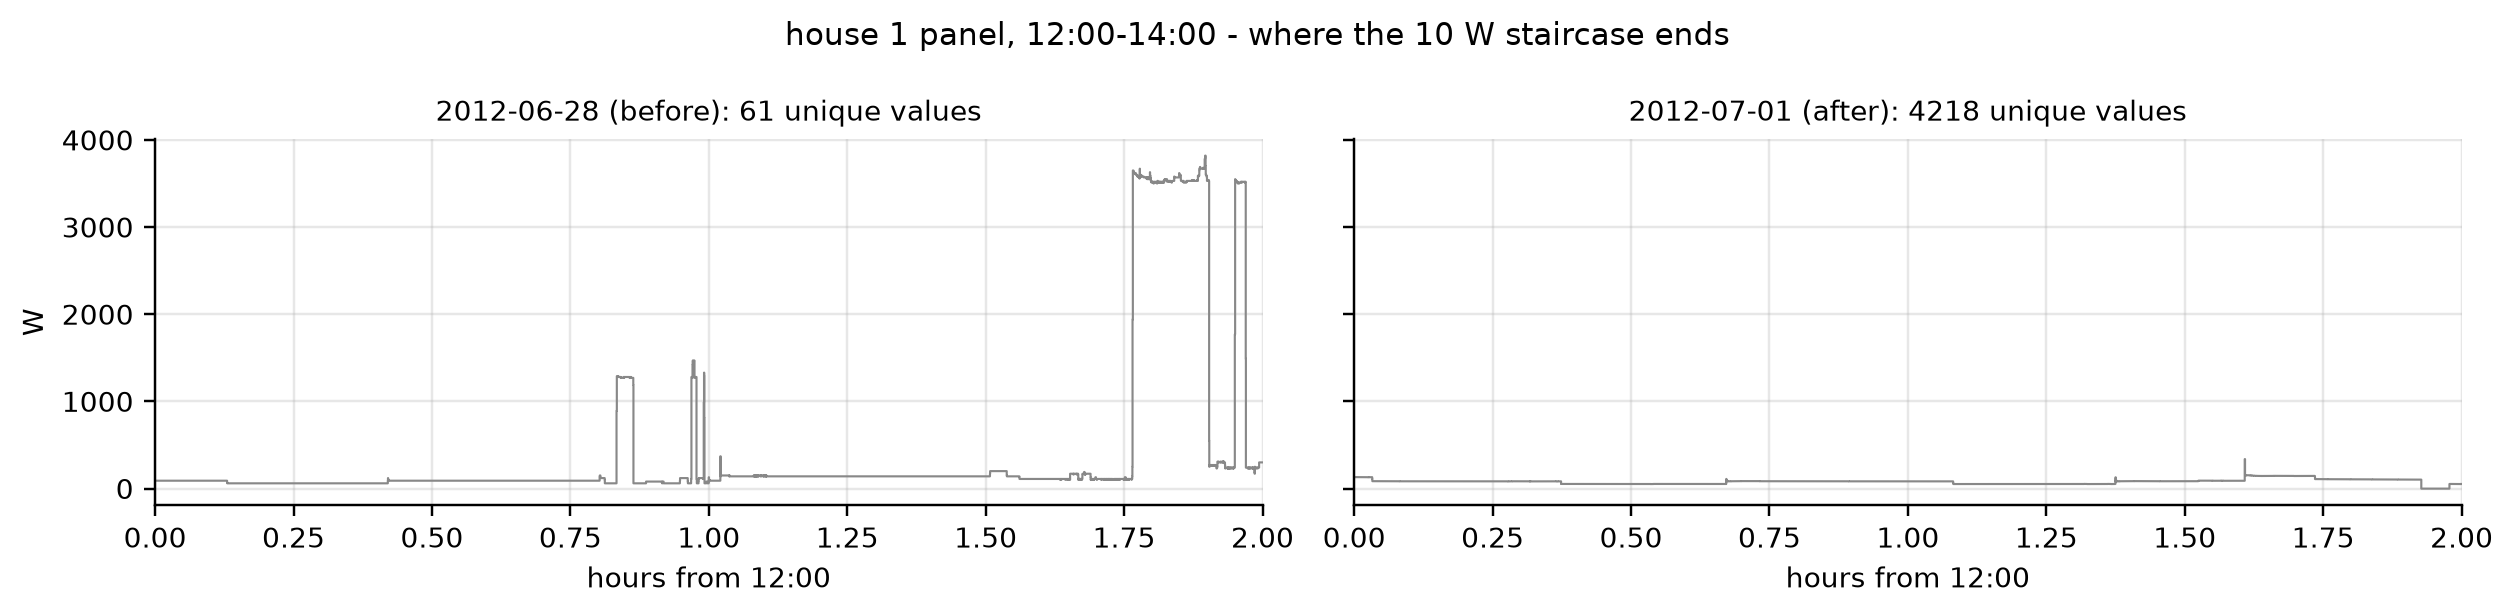

In [ ]:
_valid = v1 != -1.0
_on10 = v1 == 10.0 * np.round(v1 / 10.0)
_bad = _valid & ~_on10
_i_bnd = int(np.argmax(_bad))
bnd_ts = int(ts1[_i_bnd])
STAIR = {
    "frac_pre": float(_on10[(ts1 < bnd_ts) & _valid].mean()),
    "frac_post": float(_on10[((ts1 >= bnd_ts) & (ts1 < bnd_ts + 28 * 86_400_000_000)) & _valid].mean()),
    "pre_days": (bnd_ts - int(ts1[0])) / 86_400e6,
    "bnd_txt": pd.Timestamp(bnd_ts, unit="us").strftime("%Y-%m-%d %H:%M:%S"),
    "last_q_w": float(v1[_i_bnd - 1]),
    "bnd_val": float(v1[_i_bnd]),
    "min_pre": float(np.nanmin(np.where((ts1 < bnd_ts) & _valid, v1, np.nan))),
    "uniq_pre": int(len(np.unique(v1[(ts1 < ts1[0] + 28 * 86_400_000_000) & _valid]))),
    "uniq_post": int(len(np.unique(v1[((ts1 >= bnd_ts) & (ts1 < bnd_ts + 28 * 86_400_000_000)) & _valid]))),
}
del _valid, _on10, _bad, _i_bnd

# figure: the same two hours, one week before vs one week after the boundary
_fig, _axes = plt.subplots(1, 2, figsize=(11.5, 2.8), sharey=True)
for _ax, _day, _tag in zip(_axes, ("2012-06-28", "2012-07-01"), ("before", "after")):
    _a = int(pd.Timestamp(_day).value // 1000) + 12 * 3_600_000_000
    _m = (ts1 >= _a) & (ts1 < _a + 2 * 3_600_000_000)
    _x = (ts1[_m] - _a) / 3.6e9
    _ax.plot(_x, v1[_m], lw=0.7, drawstyle="steps-post", color=eda.canon_color("mains"))
    _vv = v1[_m]
    _vv = _vv[_vv != -1.0]
    _ax.set_title("%s (%s): %d unique values" % (_day, _tag, len(np.unique(_vv))), fontsize=9)
    _ax.set_xlabel("hours from 12:00")
    _ax.set_xlim(0, 2)
_axes[0].set_ylabel("W")
_fig.suptitle("house 1 panel, 12:00-14:00 - where the 10 W staircase ends", fontsize=10)
_fig.tight_layout()
_fig  # render figure as cell output

## Q5 - Do the labels match the physics? The full plug census

*Question: what is behind every plug label - and do the numbers agree with
the name on the board?*

ECO's plug fleet is its crown jewel, so we census all of it: every plug, its
label, its span, its duty cycle, its episode rate, its energy - plus the
-1 sentinel structure of each channel. Then we zoom into the signatures where
labels and physics disagree.

In [ ]:
PLUGS = []
GAL = {}
_nest_raw = {}
for _h in range(1, 7):
    _hdir = eda.fnd_file("eco", "house_%02d" % _h)
    _scan = SCANS[_h]
    _t0p = _scan["t0"] if _scan is not None else None
    _t1p = _scan["t1"] if _scan is not None else None
    for f in sorted(os.listdir(_hdir)):
        if not (f.startswith("plug_") and f.endswith(".parquet")):
            continue
        pid = f[5:7]
        _info = AMAP["eco"]["house_%02d" % _h]["plugs"].get(pid, {})
        label = _info.get("label", "?")
        ts, v = eda.read_channel(os.path.join(_hdir, f), value_col="consumption")
        st = eda.channel_stats(ts, v, missing_values=(-1.0,))
        kwh_full = eda.kwh_of(ts, v, missing_values=(-1.0,))
        if _t0p is not None:
            _m = (ts >= _t0p) & (ts <= _t1p)
            kwh_win = eda.kwh_of(ts[_m], v[_m], missing_values=(-1.0,))
        else:
            _m = np.ones(len(ts), dtype=bool)
            kwh_win = kwh_full
        # hour-of-day profile over the panel window (full span for house 4)
        if _t0p is not None:
            _t, _y = eda.resample_mean(ts[_m], v[_m], 3600, _t0p, _t1p)
        else:
            _t, _y = eda.resample_mean(ts, v, 3600, int(ts[0]), int(ts[-1]))
        _hh = ((np.asarray(_t) // 3_600_000_000) % 24).astype(np.int64)
        _cnt = np.bincount(_hh, minlength=24).astype(np.float64)
        hour_mean = np.bincount(_hh, weights=np.nan_to_num(np.asarray(_y)),
                                minlength=24) / np.maximum(_cnt, 1.0)
        # sentinel -1 blink structure (1 Hz rows, so run lengths are seconds)
        _si = (v == -1.0).astype(np.int8)
        _ch = np.diff(np.concatenate([[0], _si, [0]]))
        _rlens = np.diff(np.flatnonzero(_ch != 0))[::2]
        miss_n = int(_si.sum())
        miss_runs = int(len(_rlens))
        miss_max_d = float(_rlens.max()) / 86_400.0 if miss_runs else 0.0
        rec = {
            "h": _h, "pid": pid, "label": label,
            "span_d": (int(ts[-1]) - int(ts[0])) / 86_400e6,
            "valid_pct": 100.0 * (len(v) - miss_n) / len(v),
            "p50_on_w": st["p50_on_w"], "thr_on_w": st["thr_on_w"],
            "duty_pct": 100.0 * st["on_share"],
            "eps_day": st["episodes_per_day"],
            "dwell_p50_s": st["dwell_p50_s"],
            "kwh_full": kwh_full, "kwh_win": kwh_win,
            "hour_mean": hour_mean,
            "miss_share": 100.0 * miss_n / len(v),
            "miss_runs": miss_runs, "miss_max_d": miss_max_d,
            "t0": int(ts[0]), "t1": int(ts[-1]),
        }
        PLUGS.append(rec)
        if "kettle" in label.lower():
            _thr_b = max(st["thr_on_w"], 1000.0)
            _onb = (v > _thr_b).astype(np.int8)
            _db = np.diff(np.concatenate([[0], _onb, [0]]))
            _bs, _be = np.flatnonzero(_db == 1), np.flatnonzero(_db == -1)
            _kb = (_be - _bs) >= 10
            _bs, _be = _bs[_kb], _be[_kb]
            rec["boil_like_n"] = int(len(_bs))
            rec["boil_max_min"] = float(np.max(_be - _bs)) / 60.0 if len(_bs) else 0.0
            if len(_bs):
                _durs = (_be - _bs).astype(np.float64)
                _pick = int(np.argmin(np.abs(_durs - np.median(_durs))))
                _lo = max(0, int(_bs[_pick]) - 180)
                _hi = min(len(v), int(_be[_pick]) + 180)
                GAL["kettle_h%d" % _h] = (ts[_lo:_hi], v[_lo:_hi],
                                         float(v[_bs[_pick]:_be[_pick]].max()),
                                         float(_durs[_pick]))
            else:
                _i = int(np.argmax(v))
                GAL["kettle_h%d" % _h] = (ts[max(0, _i - 3600):_i + 3600],
                                         v[max(0, _i - 3600):_i + 3600],
                                         float(v[_i]), float("nan"))
            del _onb, _db, _bs, _be, _kb
        if _h == 1 and pid == "06":  # the PC that never sleeps (until it did)
            _onp = (v > st["thr_on_w"]).astype(np.int8)
            _dp = np.diff(np.concatenate([[0], _onp, [0]]))
            _ps, _pe = np.flatnonzero(_dp == 1), np.flatnonzero(_dp == -1)
            rec["pc_longest_d"] = float(np.max(_pe - _ps)) / 86_400.0 if len(_ps) else 0.0
            _t7, _y7 = eda.resample_mean(ts, v, 60, int(ts[0]) + 3_600_000_000,
                                         int(ts[-1]) - 3_600_000_000)
            GAL["pc_week"] = (_t7, _y7)
            del _onp, _dp, _ps, _pe, _t7, _y7
        if _h == 1 and pid == "03":  # coffee machine: the day it appeared
            GAL["coffee_day"] = (ts[:86_400].copy(), v[:86_400].copy())
            rec["coffee_t0_txt"] = pd.Timestamp(int(ts[0]), unit="us").strftime("%Y-%m-%d")
        if _h == 2 and pid in ("05", "11", "12"):
            _nest_raw[pid] = (ts.copy(), v.copy())
        del ts, v, st, _si, _ch, _rlens

# board table (49 rows, rendered inside a details block)
_rows = []
for _r in sorted(PLUGS, key=lambda r: (r["h"], r["pid"])):
    _rows.append((_r["h"], _r["pid"], _r["label"], "%.0f" % _r["span_d"],
                  "%.1f" % _r["valid_pct"], "%.0f" % _r["p50_on_w"],
                  "%.1f" % _r["duty_pct"], "%.1f" % _r["eps_day"],
                  "%.0f" % _r["kwh_win"]))
BOARD_TBL = mo.md(
    "<details>\n<summary><b>The full 49-plug board</b> (click to expand)</summary>\n\n"
    + eda.md_table(
        ["h", "plug", "label", "span d", "valid %", "p50 on W", "duty %", "eps/d", "kWh (panel win)"],
        _rows)
    + "\n</details>")
# house 2 nesting: Entertainment (05) vs TV (11) + Stereo (12)
_t0h2, _t1h2 = SCANS[2]["t0"], SCANS[2]["t1"]
_n60 = int((_t1h2 - _t0h2) // 60_000_000)
_g = {}
for _pid in ("05", "11", "12"):
    _ts, _vv = eda.read_channel(eda.fnd_file("eco", "house_02", "plug_%s.parquet" % _pid),
                                value_col="consumption")
    _g[_pid] = eda.resample_grid(_ts, _vv, 60, _t0h2, _n60)[1]
    del _ts, _vv
_a = _g["05"]
_b = _g["11"] + _g["12"]
_fin = np.isfinite(_a) & np.isfinite(_b)
_d = _a[_fin] - _b[_fin]
_kw2 = {_r["pid"]: _r["kwh_win"] for _r in PLUGS if _r["h"] == 2}
NEST_ST = {
    "valid_pct": float(100.0 * _fin.mean()),
    "mean_d": float(np.abs(_d).mean()),
    "p99_d": float(np.percentile(np.abs(_d), 99)),
    "corr": float(np.corrcoef(_a[_fin], _b[_fin])[0, 1]),
    "kwh_ent": _kw2["05"], "kwh_tv": _kw2["11"], "kwh_st": _kw2["12"],
    "panel_kwh": SCANS[2]["energy_kwh"],
}
_tn = _nest_raw["05"][0]
_v5n = _nest_raw["05"][1]
_tvv = _nest_raw["11"][1] + _nest_raw["12"][1]
GAL["nest"] = (_tn, _v5n, _tvv)
del _g, _a, _b, _fin, _d, _nest_raw, _tn, _v5n, _tvv

In [ ]:
BOARD_TBL  # render the full plug board

<details>
<summary><b>The full 49-plug board</b> (click to expand)</summary>

| h | plug | label | span d | valid % | p50 on W | duty % | eps/d | kWh (panel win) |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | 01 | Fridge | 237 | 98.5 | 49 | 37.1 | 23.9 | 115 |
| 1 | 02 | Dryer | 237 | 98.6 | 788 | 2.9 | 7.8 | 125 |
| 1 | 03 | Coffee machine | 131 | 85.4 | 1188 | 0.4 | 5.8 | 12 |
| 1 | 04 | Kettle | 237 | 77.7 | 1765 | 0.3 | 1.8 | 23 |
| 1 | 05 | Washing machine | 237 | 98.6 | 34 | 5.5 | 177.1 | 131 |
| 1 | 06 | PC | 79 | 84.8 | 11 | 100.0 | 0.0 | 24 |
| 1 | 07 | Freezer | 237 | 98.6 | 32 | 54.6 | 32.6 | 101 |
| 2 | 01 | Tablet | 245 | 97.4 | 9 | 0.8 | 63.7 | 7 |
| 2 | 02 | Dishwasher | 245 | 97.1 | 134 | 1.4 | 1.0 | 91 |
| 2 | 03 | Air exhaust | 245 | 97.7 | 81 | 0.7 | 0.8 | 3 |
| 2 | 04 | Fridge | 245 | 98.0 | 72 | 33.6 | 35.7 | 141 |
| 2 | 05 | Entertainment | 245 | 96.2 | 208 | 24.8 | 1.5 | 303 |
| 2 | 06 | Freezer | 245 | 96.4 | 54 | 50.8 | 43.2 | 156 |
| 2 | 07 | Kettle | 245 | 88.5 | 1838 | 0.3 | 1.3 | 28 |
| 2 | 08 | Lamp | 245 | 90.2 | 154 | 9.5 | 3.4 | 86 |
| 2 | 09 | Laptops | 245 | 83.4 | 34 | 19.1 | 27.3 | 36 |
| 2 | 10 | Stove | 49 | 100.0 | 1825 | 0.7 | 12.7 | 9 |
| 2 | 11 | TV | 245 | 100.0 | 160 | 23.4 | 2.2 | 216 |
| 2 | 12 | Stereo | 245 | 95.9 | 50 | 31.1 | 20.6 | 95 |
| 3 | 01 | Tablet | 101 | 96.0 | 9 | 1.3 | 66.9 | 3 |
| 3 | 02 | Freezer | 101 | 94.2 | 23 | 24.0 | 22.9 | 14 |
| 3 | 03 | Coffee machine | 69 | 74.6 | 9 | 1.0 | 10.6 | 1 |
| 3 | 04 | PC | 92 | 62.5 | 105 | 5.7 | 0.4 | 3 |
| 3 | 05 | Fridge | 88 | 56.1 | 64 | 25.5 | 7.1 | 10 |
| 3 | 06 | Kettle | 70 | 66.0 | 17 | 1.8 | 1.2 | 11 |
| 3 | 07 | Entertainment | 82 | 69.8 | 63 | 7.9 | 0.5 | 4 |
| 4 | 01 | Fridge | 211 | 97.0 | 94 | 29.2 | 16.8 | 126 |
| 4 | 02 | Kitchen appliances | 211 | 96.8 | 753 | 0.8 | 75.0 | 44 |
| 4 | 03 | Lamp | 201 | 93.5 | 81 | 9.8 | 19.3 | 43 |
| 4 | 04 | Stereo and laptop | 201 | 91.0 | 15 | 72.9 | 2.1 | 50 |
| 4 | 05 | Freezer | 210 | 93.1 | 179 | 90.0 | 5.6 | 775 |
| 4 | 06 | Tablet | 211 | 93.6 | 9 | 3.2 | 57.0 | 6 |
| 4 | 07 | Entertainment | 211 | 94.7 | 11 | 93.0 | 24.8 | 140 |
| 4 | 08 | Microwave | 211 | 97.1 | 1371 | 0.9 | 16.2 | 74 |
| 5 | 01 | Tablet | 219 | 97.9 | 6 | 19.2 | 6501.0 | 24 |
| 5 | 02 | Coffee machine | 219 | 95.2 | 24 | 0.6 | 37.5 | 29 |
| 5 | 03 | Fountain | 71 | 99.4 | 9 | 100.0 | 0.0 | 20 |
| 5 | 04 | Microwave | 219 | 97.9 | 7 | 48.6 | 2974.5 | 46 |
| 5 | 05 | Fridge | 219 | 97.9 | 115 | 35.6 | 20.4 | 237 |
| 5 | 06 | Entertainment | 219 | 89.1 | 9 | 61.9 | 1.7 | 114 |
| 5 | 07 | PC | 219 | 97.9 | 28 | 100.0 | 0.0 | 171 |
| 5 | 08 | Kettle | 25 | 76.6 | 9 | 4.0 | 0.5 | 0 |
| 6 | 01 | Lamp | 219 | 67.2 | 26 | 1.4 | 0.1 | 1 |
| 6 | 02 | Laptop | 219 | 97.3 | 6 | 53.1 | 2199.5 | 29 |
| 6 | 03 | Router | 88 | 96.7 | 19 | 100.0 | 0.0 | 41 |
| 6 | 04 | Coffee machine | 219 | 86.0 | 315 | 0.9 | 226.3 | 16 |
| 6 | 05 | Entertainment | 219 | 95.9 | 15 | 100.0 | 0.0 | 102 |
| 6 | 06 | Fridge | 219 | 95.8 | 47 | 19.6 | 53.9 | 44 |
| 6 | 07 | Kettle | 158 | 82.5 | 2025 | 0.2 | 0.5 | 9 |
</details>

In [ ]:
_R = {(_r["h"], _r["pid"]): _r for _r in PLUGS}
_fr, _dr, _kt = _R[(1, "01")], _R[(1, "02")], _R[(1, "04")]
_wa, _pc, _fz = _R[(1, "05")], _R[(1, "06")], _R[(1, "07")]
_kt2, _kt3, _kt5 = _R[(2, "07")], _R[(3, "06")], _R[(5, "08")]
_e5, _tv, _st = _R[(2, "05")], _R[(2, "11")], _R[(2, "12")]
mo.md(f"""
**Reading it.** The board mostly *is* what it claims to be - and the census
quantifies exactly where it is not. The cold appliances behave like
textbooks: flat 1's fridge idles at a **{_fr["p50_on_w"]:.0f} W** median with
a **{_fr["duty_pct"]:.0f}%** duty cycle ({_fr["kwh_win"]:.0f} kWh) while the
freezer runs harder (**{_fz["duty_pct"]:.0f}%**, {_fz["kwh_win"]:.0f} kWh).
The kettle is the model citizen - {_kt["eps_day"]:.1f} episodes a day. The
washing machine shows the census trap: **{_wa["eps_day"]:.0f} episodes/day**
at a {_wa["p50_on_w"]:.0f} W median, because the electronics idle between
programs; episodes are not cycles.

Then the oddities. Flat 1 plug 06, labelled PC, sits at
**{_pc["duty_pct"]:.2f}%** duty - the longest single run is
**{_pc["pc_longest_d"]:.1f} days** without a blink, and the channel goes dark
for good on {pd.Timestamp(_pc["t1"], unit="us").strftime("%Y-%m-%d")}.
Flat 1 plug 03 (coffee machine) only *exists* from
{_R[(1, "03")]["coffee_t0_txt"]} - mid-study, when a machine moved in; any
"appliance always present" assumption breaks here. The kettles disagree
wildly: flat 1 draws {_kt["p50_on_w"]:.0f} W at the median on-sample, flat 2
{_kt2["p50_on_w"]:.0f} W - but flat 3's "kettle" spends most of its time at
single-digit watts (duty {_kt3["duty_pct"]:.1f}%) and flat 5's at
{_kt5["p50_on_w"]:.0f} W. Same label, different physics. And the nesting
find: flat 2's Entertainment plug tracks TV + Stereo at
r = {NEST_ST["corr"]:.3f} (details in Q8).

The -1 sentinel is not cosmetic either: flat 1's kettle channel is
**{_kt["miss_share"]:.1f}%** missing, shattered into
{_kt["miss_runs"]:,} separate blink-runs, the longest stretching
{_kt["miss_max_d"]:.1f} days. **[insight only]** Any NILM training loop that
treats -1 as a reading will learn a phantom 15-day boil.
""")

**Reading it.** The board mostly *is* what it claims to be - and the census
quantifies exactly where it is not. The cold appliances behave like
textbooks: flat 1's fridge idles at a **49 W** median with
a **37%** duty cycle (115 kWh) while the
freezer runs harder (**55%**, 101 kWh).
The kettle is the model citizen - 1.8 episodes a day. The
washing machine shows the census trap: **177 episodes/day**
at a 34 W median, because the electronics idle between
programs; episodes are not cycles.

Then the oddities. Flat 1 plug 06, labelled PC, sits at
**100.00%** duty - the longest single run is
**7.6 days** without a blink, and the channel goes dark
for good on 2012-08-18.
Flat 1 plug 03 (coffee machine) only *exists* from
2012-09-15 - mid-study, when a machine moved in; any
"appliance always present" assumption breaks here. The kettles disagree
wildly: flat 1 draws 1765 W at the median on-sample, flat 2
1838 W - but flat 3's "kettle" spends most of its time at
single-digit watts (duty 1.8%) and flat 5's at
9 W. Same label, different physics. And the nesting
find: flat 2's Entertainment plug tracks TV + Stereo at
r = 0.992 (details in Q8).

The -1 sentinel is not cosmetic either: flat 1's kettle channel is
**22.3%** missing, shattered into
207,734 separate blink-runs, the longest stretching
1.6 days. **[insight only]** Any NILM training loop that
treats -1 as a reading will learn a phantom 15-day boil.

## Q6 - The signature gallery: what each appliance actually looks like

*Question: if you had never seen these plugs, what would you mistake for
what?*

Numbers in a table flatten appliances into rows. So: five kettles side by
side, then the four signatures every disaggregation model must survive -
the washer's program, the fridge/freezer sawtooth pair, the PC that never
sleeps, and the coffee machine's first morning.

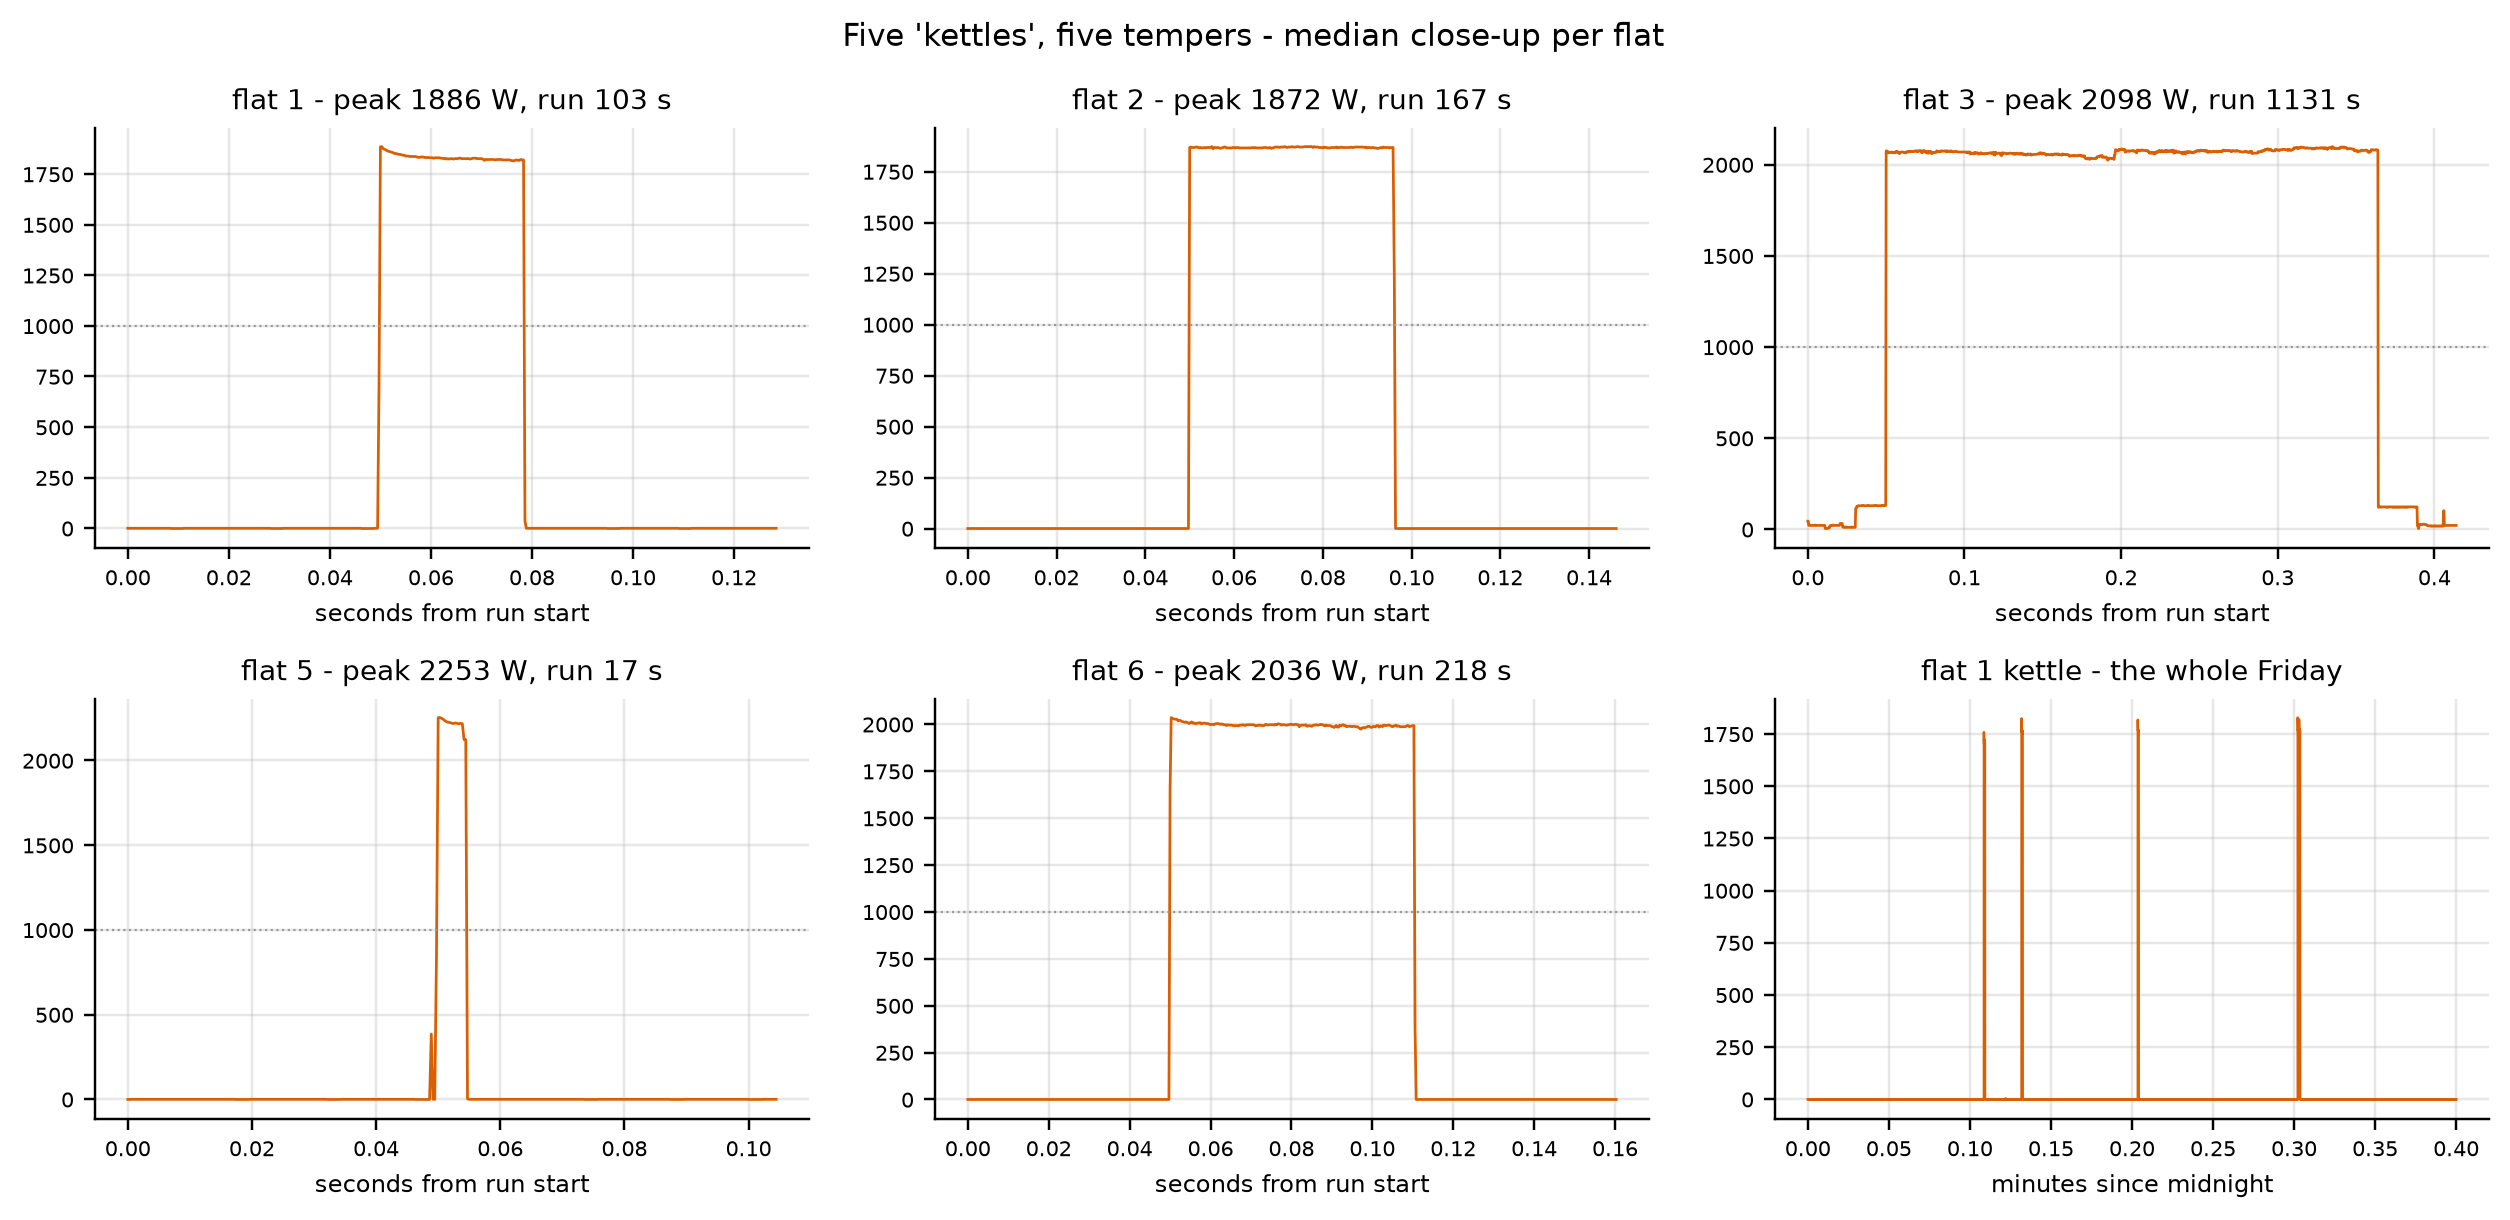

In [ ]:
_fig, _axs = plt.subplots(2, 3, figsize=(11.5, 5.6))
for _i, _h in enumerate((1, 2, 3, 5, 6)):
    _t, _v, _pk, _du = GAL["kettle_h%d" % _h]
    _x = (np.asarray(_t, dtype=np.int64) - int(_t[0])) / 3.6e9
    _ax = _axs.ravel()[_i]
    _ax.plot(_x, np.asarray(_v), lw=0.9, color=eda.canon_color("kettle"))
    _ax.axhline(1000.0, color="0.6", lw=0.7, ls=":")
    _ax.set_title("flat %d - peak %.0f W, run %.0f s" % (_h, _pk, _du), fontsize=9)
    _ax.set_xlabel("seconds from run start", fontsize=8)
_km = (k_ts >= hero_a) & (k_ts < hero_a + 86_400_000_000)
_ax6 = _axs.ravel()[5]
_ax6.plot((k_ts[_km] - hero_a) / 3.6e9 / 60.0, k_v[_km], lw=0.8,
          color=eda.canon_color("kettle"))
_ax6.set_title("flat 1 kettle - the whole Friday", fontsize=9)
_ax6.set_xlabel("minutes since midnight", fontsize=8)
for _ax in _axs.ravel():
    _ax.tick_params(labelsize=7)
_fig.suptitle("Five 'kettles', five tempers - median close-up per flat", fontsize=10)
_fig.tight_layout()
_fig  # render figure as cell output

In [ ]:
_R = {(_r["h"], _r["pid"]): _r for _r in PLUGS}
_kt3, _kt5 = _R[(3, "06")], _R[(5, "08")]
mo.md(f"""
**Reading it.** Flats 1, 2 and 6 own honest kettles: a
{GAL["kettle_h1"][2]:.0f} / {GAL["kettle_h2"][2]:.0f} /
{GAL["kettle_h6"][2]:.0f} W wall, up, boil, down, in about a minute. Flat 3's
"kettle" is a different animal - the median close-up shows a
{GAL["kettle_h3"][2]:.0f} W plateau that can hold for
{GAL["kettle_h3"][3] / 60.0:.0f} minutes (its {GAL["kettle_h3"][2]:.0f} W
peak is a kettle *inside* something else), and it spends only
{_kt3["duty_pct"]:.1f}% of its life on. Flat 5's is dormant almost
throughout - {GAL["kettle_h5"][2]:.0f} W peaks on just a handful of days.
**[insight only]** A model trained on flat 1's kettle would mislabel flat 3's
appliance forever: the label says kettle, the physics says hot plate.
""")

**Reading it.** Flats 1, 2 and 6 own honest kettles: a
1886 / 1872 /
2036 W wall, up, boil, down, in about a minute. Flat 3's
"kettle" is a different animal - the median close-up shows a
2098 W plateau that can hold for
19 minutes (its 2098 W
peak is a kettle *inside* something else), and it spends only
1.8% of its life on. Flat 5's is dormant almost
throughout - 2253 W peaks on just a handful of days.
**[insight only]** A model trained on flat 1's kettle would mislabel flat 3's
appliance forever: the label says kettle, the physics says hot plate.

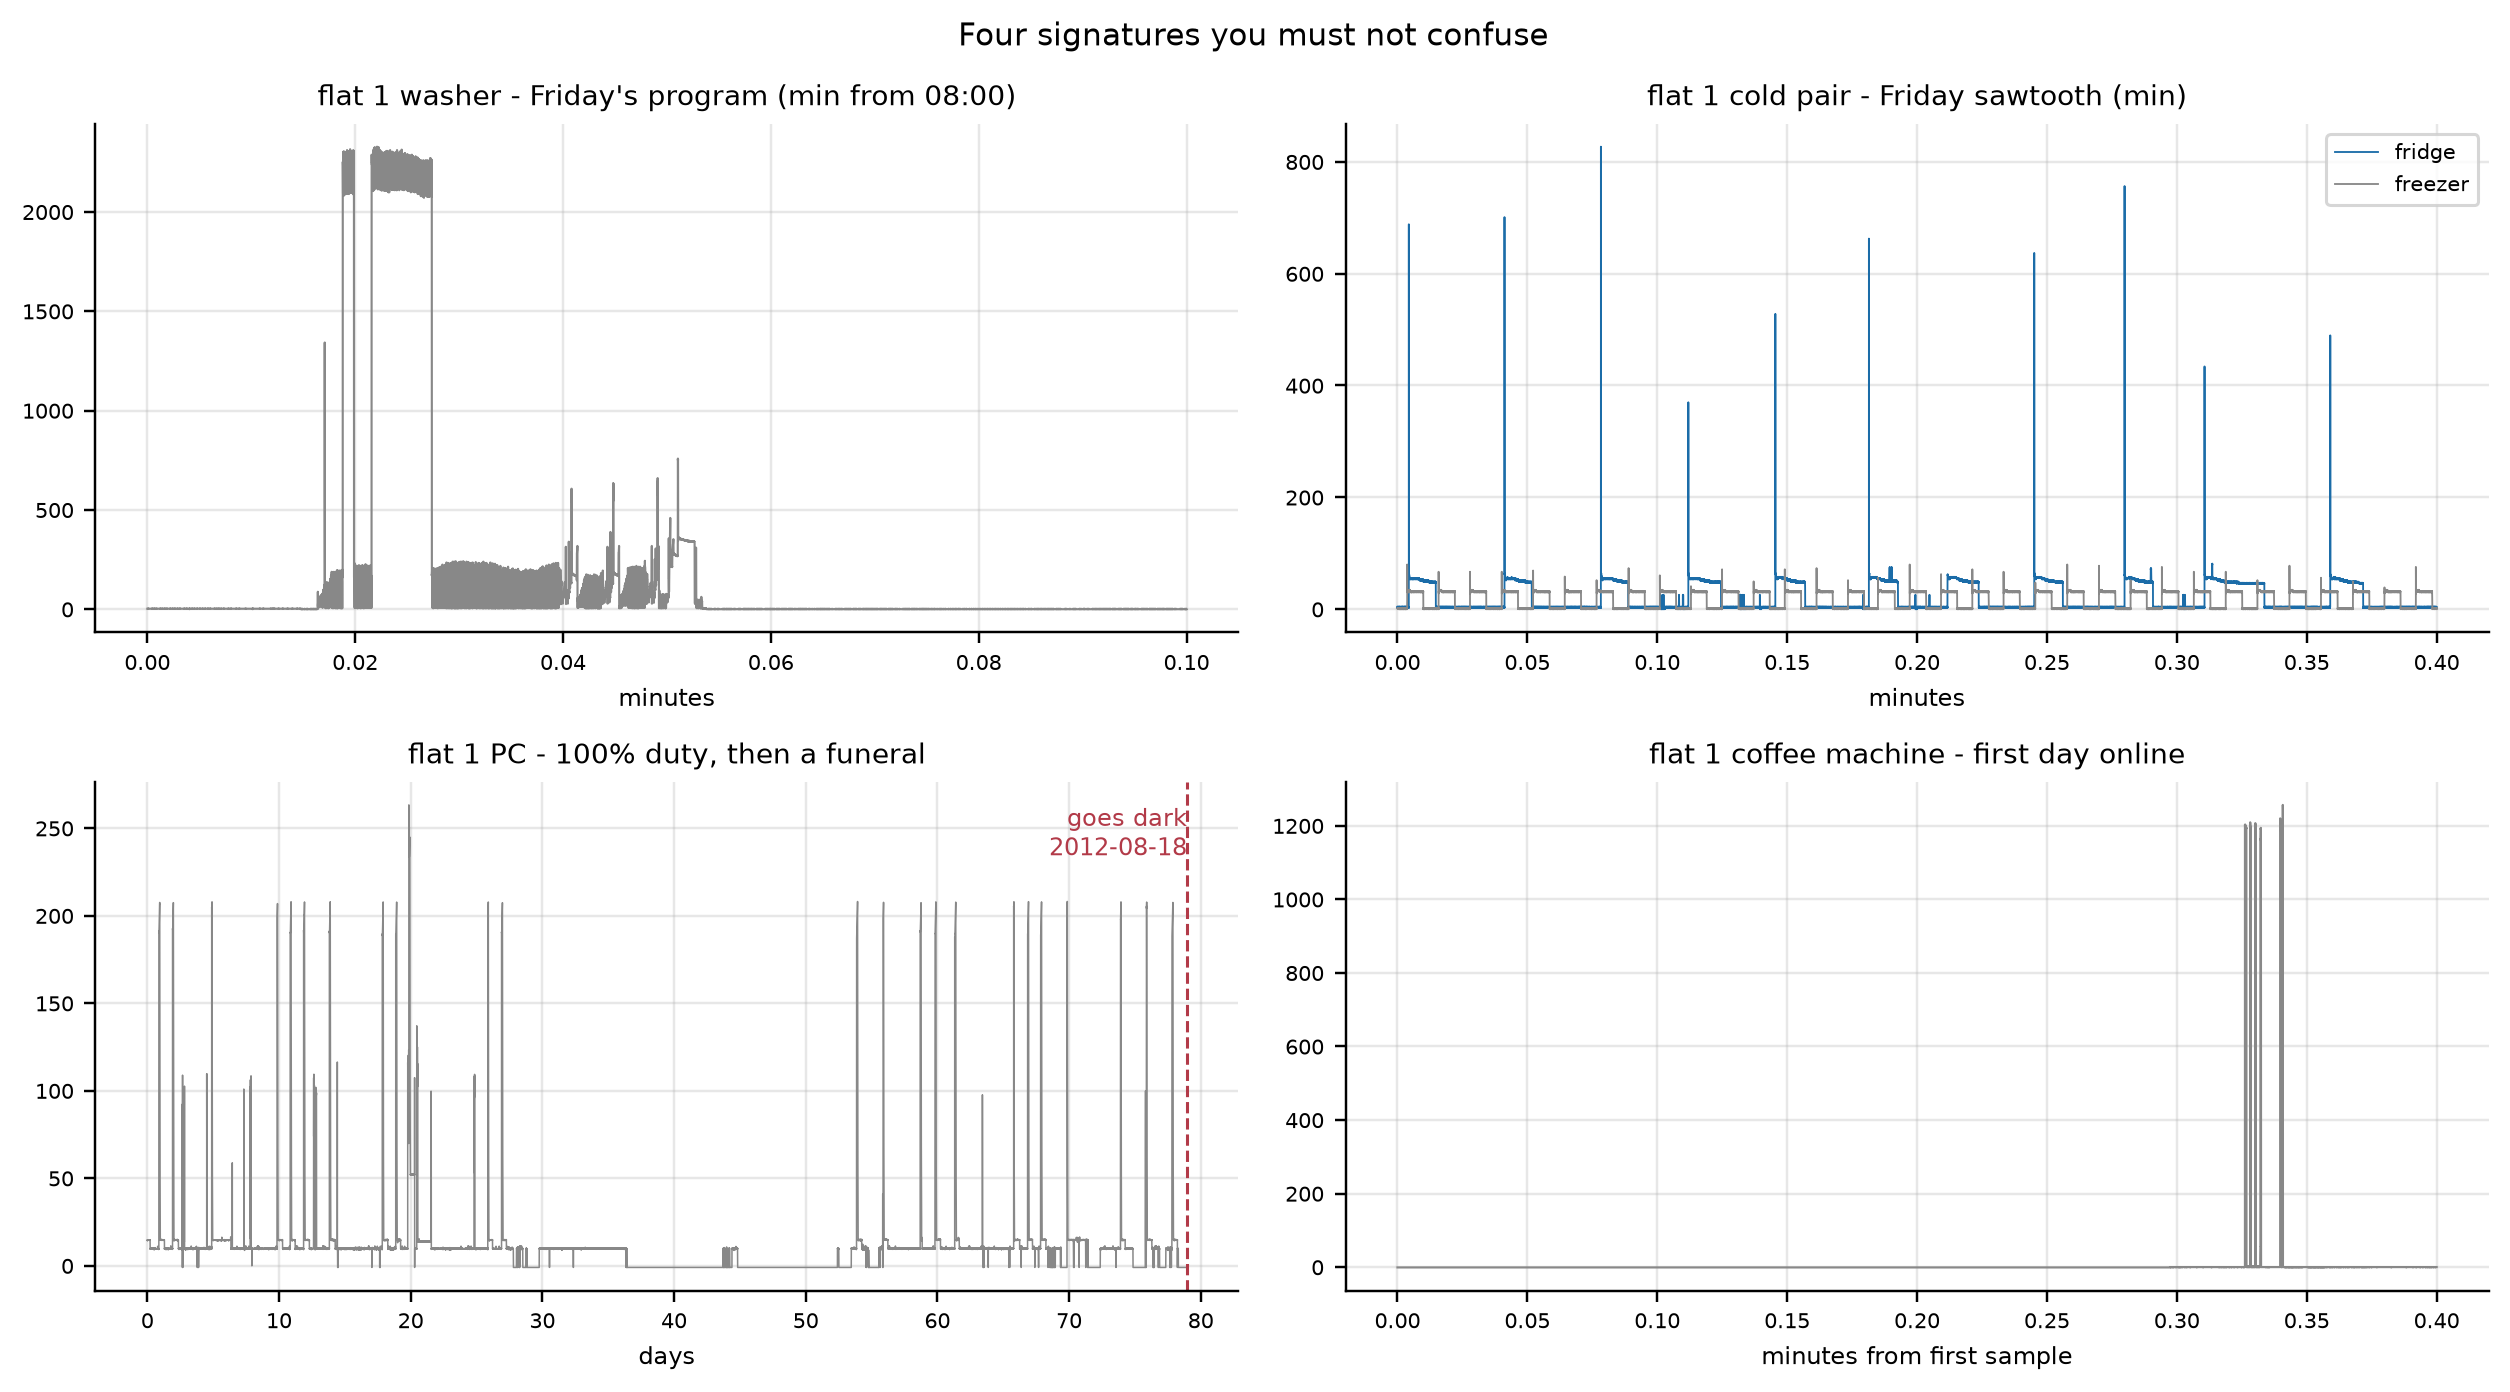

In [ ]:
_fig, _axs = plt.subplots(2, 2, figsize=(11.5, 6.4))
_ax = _axs[0, 0]
_t, _v = wash_zoom
_ax.plot((np.asarray(_t, dtype=np.int64) - int(_t[0])) / 3.6e9 / 60.0,
         np.asarray(_v), lw=0.7, color=eda.canon_color("washing machine"))
_ax.set_title("flat 1 washer - Friday's program (min from 08:00)", fontsize=9)
_ax.set_xlabel("minutes", fontsize=8)
_ax = _axs[0, 1]
for _dat, _lab in ((fridge_day, "fridge"), (freezer_day, "freezer")):
    _t, _v = _dat
    _ax.plot((np.asarray(_t, dtype=np.int64) - hero_a) / 3.6e9 / 60.0,
             np.asarray(_v), lw=0.6, label=_lab,
             color=eda.canon_color(_lab))
_ax.legend(fontsize=7)
_ax.set_title("flat 1 cold pair - Friday sawtooth (min)", fontsize=9)
_ax.set_xlabel("minutes", fontsize=8)
_ax = _axs[1, 0]
_t, _v = GAL["pc_week"]
_x = (np.asarray(_t, dtype=np.int64) - int(_t[0])) / 86_400e6
_ax.plot(_x, np.asarray(_v), lw=0.5, color=eda.canon_color("pc"))
_pc = [ _r for _r in PLUGS if _r["h"] == 1 and _r["pid"] == "06" ][0]
_ax.axvline((_pc["t1"] - int(_t[0])) / 86_400e6, color="#b23a48", lw=1.0, ls="--")
_ax.annotate("goes dark\n" + pd.Timestamp(_pc["t1"], unit="us").strftime("%Y-%m-%d"),
             xy=((_pc["t1"] - int(_t[0])) / 86_400e6, float(np.nanmax(_v))),
             fontsize=8, color="#b23a48", ha="right", va="top")
_ax.set_title("flat 1 PC - 100% duty, then a funeral", fontsize=9)
_ax.set_xlabel("days", fontsize=8)
_ax = _axs[1, 1]
_t, _v = GAL["coffee_day"]
_ax.plot((np.asarray(_t, dtype=np.int64) - int(_t[0])) / 3.6e9 / 60.0,
         np.asarray(_v), lw=0.7, color=eda.canon_color("coffee machine"))
_ax.set_title("flat 1 coffee machine - first day online", fontsize=9)
_ax.set_xlabel("minutes from first sample", fontsize=8)
for _ax in _axs.ravel():
    _ax.tick_params(labelsize=7)
_fig.suptitle("Four signatures you must not confuse", fontsize=10)
_fig.tight_layout()
_fig  # render figure as cell output

In [ ]:
_R = {(_r["h"], _r["pid"]): _r for _r in PLUGS}
_wa, _pc = _R[(1, "05")], _R[(1, "06")]
mo.md(f"""
**Reading it.** The washer is the disaggregation textbook case: a
**{_wa["p50_on_w"]:.0f} W** idle hum for hours, then a real program -
Friday's started at **{wash_start_txt}** and ran **{wash_dur_min:.0f}
minutes**, peaking at **{wash_peak_w:.0f} W** on the heater plateau. The
census warns about the trap: {_wa["eps_day"]:.0f} starts/day, most of them
just the idle electronics crossing threshold. The cold pair teaches the opposite
lesson - fridge and freezer are near-identical sawtooths whose *phase*
differs; only the duty cycle separates them. The PC is a duty-cycle trap:
**{_pc["duty_pct"]:.2f}%** on for {_pc["pc_longest_d"]:.0f}-day stretches, so
any "always-on = fridge" heuristic claims the PC too. And the coffee machine
simply appears one day: plug 03 wakes on
{_R[(1, '03')]["coffee_t0_txt"]}, which turns "appliance roster" into
a time-dependent question. **[collectable]** These four signatures - heater
plateau, cold sawtooth, always-on base, mid-study arrival - are exactly the
test cases a Shelly-fleet evaluation should include.
""")

**Reading it.** The washer is the disaggregation textbook case: a
**34 W** idle hum for hours, then a real program -
Friday's started at **09:17** and ran **21
minutes**, peaking at **2328 W** on the heater plateau. The
census warns about the trap: 177 starts/day, most of them
just the idle electronics crossing threshold. The cold pair teaches the opposite
lesson - fridge and freezer are near-identical sawtooths whose *phase*
differs; only the duty cycle separates them. The PC is a duty-cycle trap:
**100.00%** on for 8-day stretches, so
any "always-on = fridge" heuristic claims the PC too. And the coffee machine
simply appears one day: plug 03 wakes on
2012-09-15, which turns "appliance roster" into
a time-dependent question. **[collectable]** These four signatures - heater
plateau, cold sawtooth, always-on base, mid-study arrival - are exactly the
test cases a Shelly-fleet evaluation should include.

## Q7 - Is anybody home? The ground-truth occupancy labels

*Question: ECO ships manually annotated occupancy - how much load does
"being home" actually explain, and how well do the labels line up with the
panel?*

Five of the six flats carry occupancy labels in two windows each (summer and
winter, a few weeks apiece, 1 Hz, flat 6 none at all). This is the dataset's
third data track - and the closest thing NILM gets to free context.

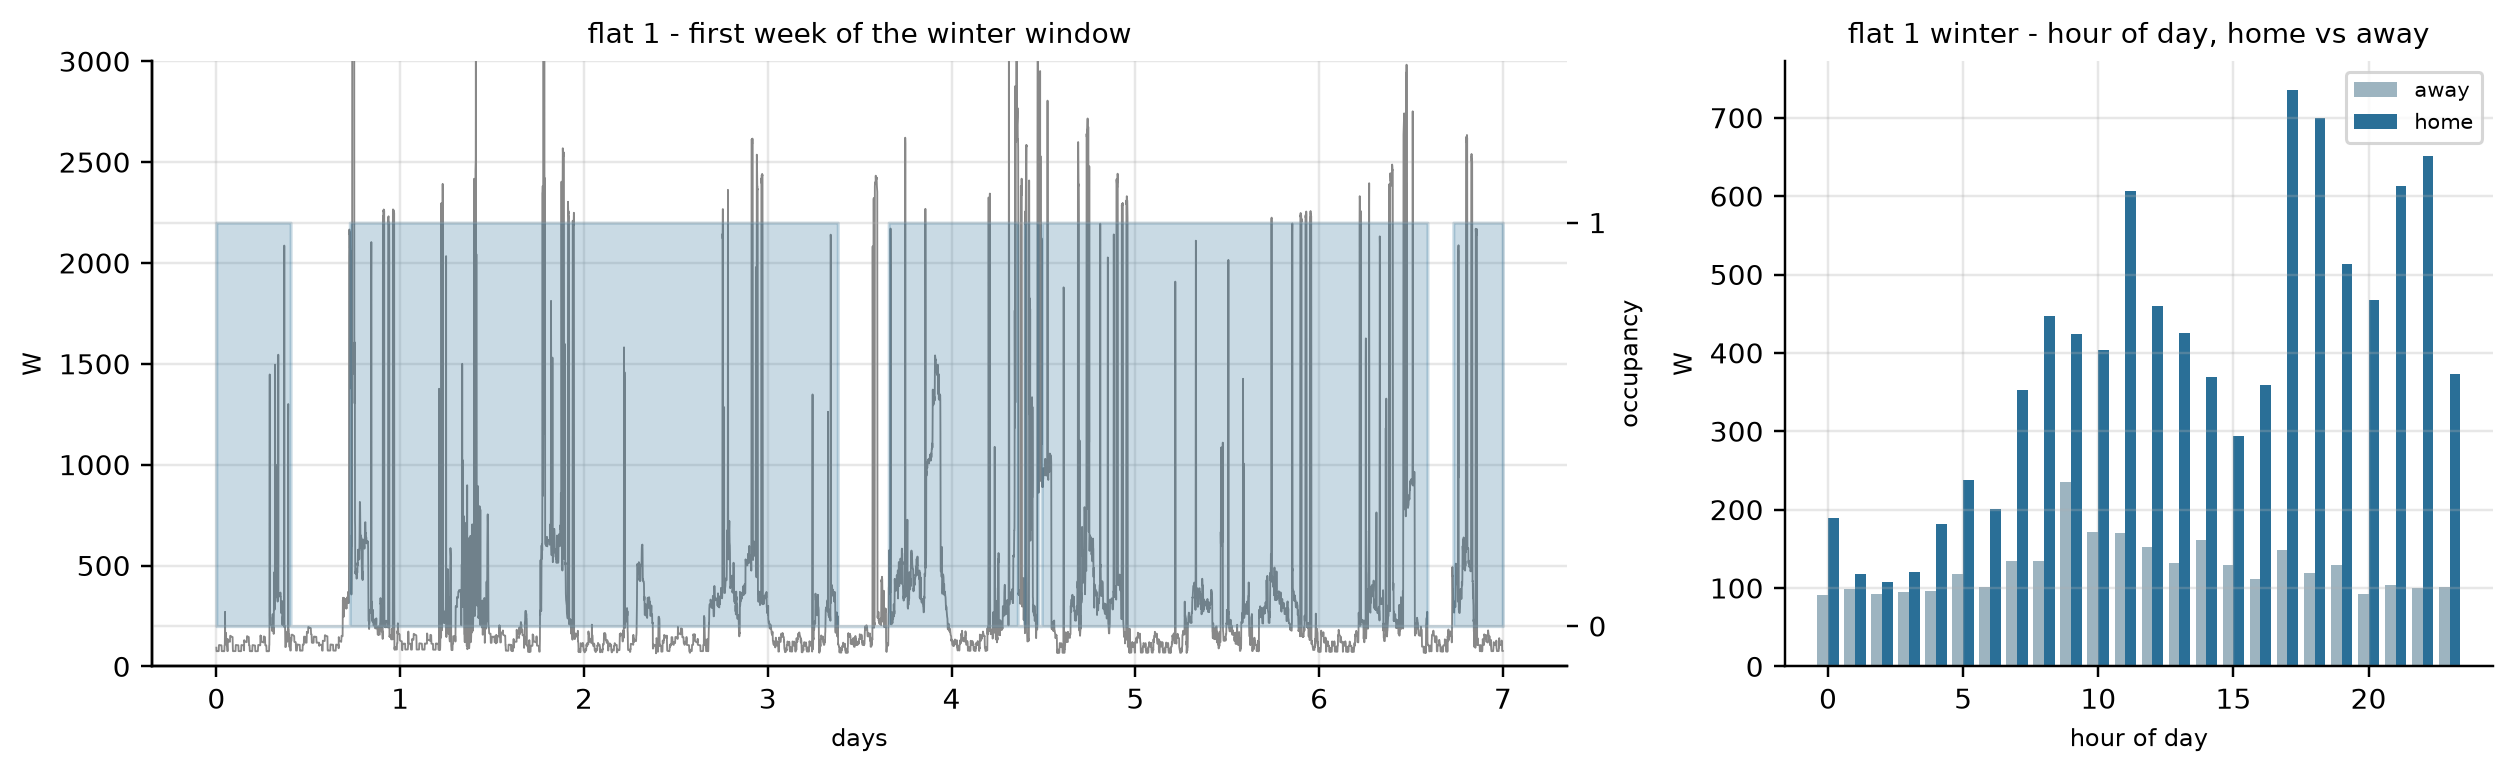

In [ ]:
OCC = {}
for _h in range(1, 6):
    OCC[_h] = {}
    for _k in OCC_FILES[_h]:
        _tb = pq.read_table(eda.fnd_file("eco", "house_%02d" % _h,
                                         "occupancy_%s.parquet" % _k))
        OCC[_h][_k] = (_tb["ts_us"].to_numpy().astype(np.int64),
                       _tb["occupancy"].to_numpy())
_rows = []
for _h in range(1, 6):
    for _k in OCC_FILES[_h]:
        _t, _o = OCC[_h][_k]
        _rows.append((_h, _k, "%.0f" % ((_t[-1] - _t[0]) / 86_400e6),
                      "%.1f" % (100.0 * (_o > 0).mean())))
OCC_TBL = mo.md(eda.md_table(["flat", "window", "days", "occupied %"], _rows))
# align flat 1's winter labels onto the panel's minute grid
_t0p, _t1p = SCANS[1]["t0"], SCANS[1]["t1"]
_n60 = int((_t1p - _t0p) // 60_000_000)
_p60 = eda.resample_grid(ts1, v1, 60, _t0p, _n60)[1]
_ot, _ov = OCC[1]["winter"]
_grid_t = _t0p + np.arange(_n60) * 60_000_000
_oi = np.clip(np.searchsorted(_ot, _grid_t, side="right") - 1, 0, len(_ot) - 1)
_near = np.abs(_ot[_oi] - _grid_t) <= 60_000_000
_occ = _near & (_ov[_oi] > 0)
_vac = _near & ~(_ov[_oi] > 0)
_hh = ((_grid_t // 3_600_000_000) % 24).astype(np.int64)
OCC_ST = {
    "occ_w": float(np.nanmean(_p60[_occ])),
    "vac_w": float(np.nanmean(_p60[_vac])),
    "eve_occ_w": float(np.nanmean(_p60[_occ & (_hh >= 20)])),
    "eve_vac_w": float(np.nanmean(_p60[_vac & (_hh >= 20)])),
    "occ_pct": float(100.0 * _occ.sum() / _near.sum()),
}
_fig, _axs = plt.subplots(1, 2, figsize=(11.5, 3.6),
                          gridspec_kw={"width_ratios": [2, 1]})
_axA = _axs[0]
_wk = (_grid_t >= _ot[0]) & (_grid_t < _ot[0] + 7 * 86_400_000_000)
_xw = (_grid_t[_wk] - _ot[0]) / 86_400e6
_axA.plot(_xw, _p60[_wk], lw=0.6, color=eda.canon_color("mains"))
_axA.set_ylim(0, 3000)
_axB = _axA.twinx()
_axB.fill_between(_xw, 0, _ov[_oi][_wk].astype(float), step="mid",
                  alpha=0.25, color="#2a6f97")
_axB.set_ylim(-0.1, 1.4)
_axB.set_yticks([0, 1])
_axB.set_ylabel("occupancy", fontsize=8)
_axA.set_title("flat 1 - first week of the winter window", fontsize=9)
_axA.set_xlabel("days", fontsize=8)
_axA.set_ylabel("W", fontsize=8)
_axP = _axs[1]
_xh = np.arange(24)
_vac_h = np.array([np.nanmean(_p60[_vac & (_hh == _g)]) for _g in _xh])
_occ_h = np.array([np.nanmean(_p60[_occ & (_hh == _g)]) for _g in _xh])
_axP.bar(_xh - 0.2, _vac_h, width=0.4, label="away", color="#9db4c0")
_axP.bar(_xh + 0.2, _occ_h, width=0.4, label="home", color="#2a6f97")
_axP.legend(fontsize=7)
_axP.set_title("flat 1 winter - hour of day, home vs away", fontsize=9)
_axP.set_xlabel("hour of day", fontsize=8)
_axP.set_ylabel("W", fontsize=8)
_fig.tight_layout()
_fig  # render figure as cell output

In [ ]:
OCC_TBL  # render the occupancy window table

| flat | window | days | occupied % |
| --- | --- | --- | --- |
| 1 | summer | 42 | 82.2 |
| 1 | winter | 47 | 75.5 |
| 2 | summer | 95 | 74.1 |
| 2 | winter | 47 | 71.2 |
| 3 | summer | 80 | 76.2 |
| 3 | winter | 32 | 74.4 |
| 4 | summer | 49 | 92.1 |
| 4 | winter | 54 | 94.3 |
| 5 | summer | 44 | 92.8 |
| 5 | winter | 36 | 86.4 |

In [ ]:
_pct = {(_h, _k): 100.0 * (_o > 0).mean()
        for _h, _w in OCC.items() for _k, (_t, _o) in _w.items()}
mo.md(f"""
**Reading it.** Two findings, one reassuring and one deflating. Reassuring:
the labels line up with the panel - in flat 1's winter window the flat draws
**{OCC_ST["occ_w"]:.0f} W** while somebody is home versus
**{OCC_ST["vac_w"]:.0f} W** while away, and in the 20:00-23:00 hours the gap
widens to {OCC_ST["eve_occ_w"]:.0f} vs {OCC_ST["eve_vac_w"]:.0f} W. The
evening hours are exactly where "home" should mean lights, cooking, TV -
and it does. **[collectable]** Occupancy-conditioned evaluation is possible
out of the box in five of six flats.

Deflating: the flats are home far more often than you would guess -
occupied {_pct[(1, "winter")]:.0f}% of flat 1's winter window, and
{_pct[(4, "winter")]:.0f}% / {_pct[(5, "winter")]:.0f}% for flats 4 and 5.
With baseline loads (fridges, freezers, that PC) running around the clock,
occupancy explains less of the variance than the hour-of-day clock does -
which is exactly why Q2's diurnal shape matters for any model. And flat 6
ships **no labels at all**: the census's 6th flat is a train-only house.
""")

**Reading it.** Two findings, one reassuring and one deflating. Reassuring:
the labels line up with the panel - in flat 1's winter window the flat draws
**383 W** while somebody is home versus
**135 W** while away, and in the 20:00-23:00 hours the gap
widens to 526 vs 99 W. The
evening hours are exactly where "home" should mean lights, cooking, TV -
and it does. **[collectable]** Occupancy-conditioned evaluation is possible
out of the box in five of six flats.

Deflating: the flats are home far more often than you would guess -
occupied 75% of flat 1's winter window, and
94% / 86% for flats 4 and 5.
With baseline loads (fridges, freezers, that PC) running around the clock,
occupancy explains less of the variance than the hour-of-day clock does -
which is exactly why Q2's diurnal shape matters for any model. And flat 6
ships **no labels at all**: the census's 6th flat is a train-only house.

## Q8 - Who burned the watts? Attribution, nesting, and the fleet's limits

*Question: how much of the panel's energy can the plugs explain - and where
do double counting, dropout and missing panel data bend the answer?*

The money question for a disaggregation dataset. Raw socket sums overcount
where plugs are nested, panels drop out, and one flat has no panel at all.
The honest accounting, house by house.

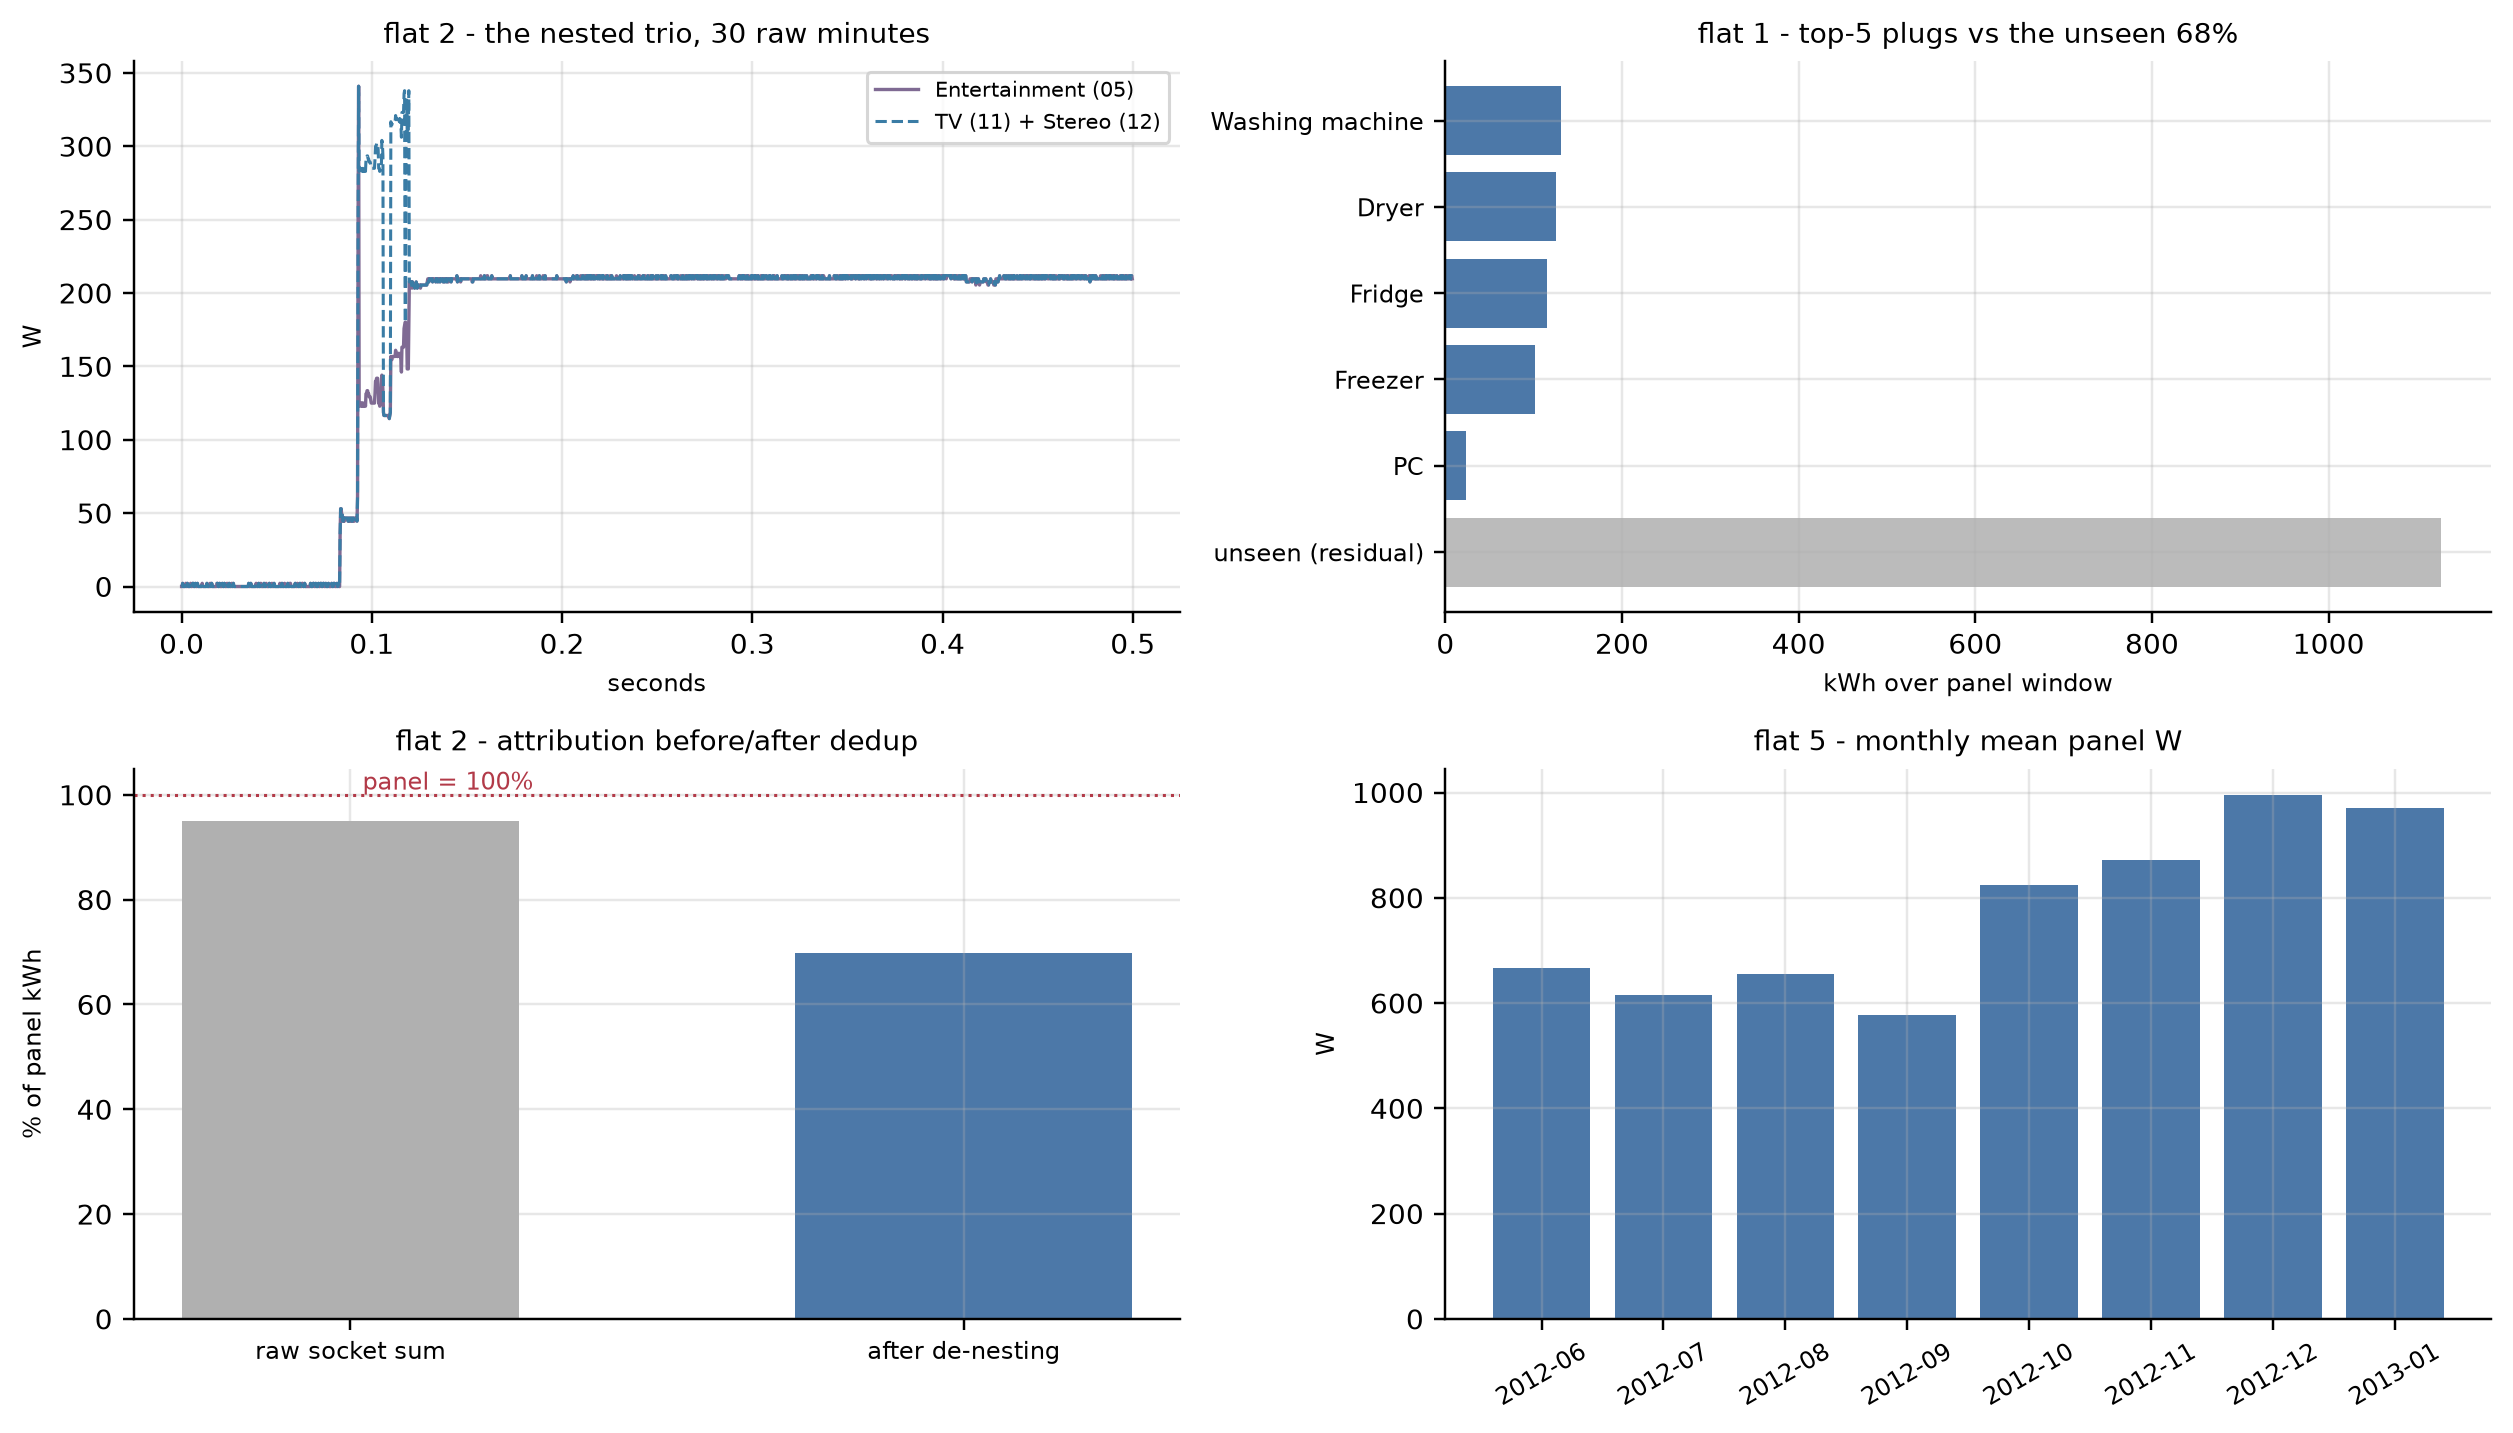

In [ ]:
ATTR = {}
for _h in range(1, 7):
    _pk = float(sum(_r["kwh_win"] for _r in PLUGS if _r["h"] == _h))
    _pf = float(sum(_r["kwh_full"] for _r in PLUGS if _r["h"] == _h))
    _scan = SCANS[_h]
    ATTR[_h] = {
        "plug_kwh": _pk,
        "plug_kwh_full": _pf,
        "panel_kwh": float(_scan["energy_kwh"]) if _scan is not None else float("nan"),
        "share_pct": (100.0 * _pk / _scan["energy_kwh"]) if _scan is not None else float("nan"),
    }
ATTR[2]["dedup_kwh"] = ATTR[2]["plug_kwh"] - NEST_ST["kwh_tv"] - NEST_ST["kwh_st"]
ATTR[2]["dedup_pct"] = 100.0 * ATTR[2]["dedup_kwh"] / ATTR[2]["panel_kwh"]
# plug energy recorded while the panel was dark (multi-day outages only)
for _h in (2, 3, 5, 6):
    _tot = 0.0
    for _gt0, _gdur in SM_GAPS[_h]:
        if _gdur < 3 * 86_400.0:
            continue
        for _r in PLUGS:
            if _r["h"] != _h or _gt0 > _r["t1"] or _gt0 + _gdur * 1e6 < _r["t0"]:
                continue
            _ts_p, _v_p = eda.read_channel(
                eda.fnd_file("eco", "house_%02d" % _h, "plug_%s.parquet" % _r["pid"]),
                value_col="consumption")
            _mg = (_ts_p >= _gt0) & (_ts_p <= _gt0 + _gdur * 1e6)
            _tot += eda.kwh_of(_ts_p[_mg], _v_p[_mg], missing_values=(-1.0,))
            del _ts_p, _v_p
    ATTR[_h]["outage_kwh"] = _tot
# flat 5: the house that never sleeps - monthly drift + night base
_ts5, _v5 = eda.read_channel(eda.fnd_file("eco", "house_05", "sm.parquet"),
                             value_col="powerallphases")
_mons = _ts5.astype("datetime64[us]").astype("datetime64[M]")
_um = np.unique(_mons)
_mw = [float(np.nanmean(_v5[_mons == _m])) for _m in _um]
_hh5 = ((_ts5 // 3_600_000_000) % 24).astype(np.int64)
H5_ST = {
    "months": [str(_m)[:7] for _m in _um],
    "month_mean_w": _mw,
    "night_mean_w": float(np.nanmean(_v5[_hh5 < 5])),
    "night_med_w": float(np.nanmedian(_v5[_hh5 < 5])),
}
del _ts5, _v5, _mons, _um, _mw, _hh5
# figure: nesting proof + attribution bars + flat 5 seasonality
_fig, _axs = plt.subplots(2, 2, figsize=(11.5, 6.6))
_axA = _axs[0, 0]
_t5n, _v5e, _vtv = GAL["nest"]
_on = np.flatnonzero(_vtv > 30.0)
_s = max(0, int(_on[0]) - 300)
_e = _s + 1800
_x = (np.asarray(_t5n[_s:_e], dtype=np.int64) - int(_t5n[_s])) / 3.6e9
_axA.plot(_x, _v5e[_s:_e], lw=1.1, color="#7f6a93", label="Entertainment (05)")
_axA.plot(_x, _vtv[_s:_e], lw=1.0, ls="--", color="#3a7ca5", label="TV (11) + Stereo (12)")
_axA.legend(fontsize=7)
_axA.set_title("flat 2 - the nested trio, 30 raw minutes", fontsize=9)
_axA.set_xlabel("seconds", fontsize=8)
_axA.set_ylabel("W", fontsize=8)
_axB = _axs[0, 1]
_r1 = sorted((_r for _r in PLUGS if _r["h"] == 1), key=lambda r: -r["kwh_win"])[:5]
_labs = [AMAP["eco"]["house_01"]["plugs"][_r["pid"]]["label"] for _r in _r1]
_vals = [_r["kwh_win"] for _r in _r1]
_labs.append("unseen (residual)")
_vals.append(ATTR[1]["panel_kwh"] - ATTR[1]["plug_kwh"])
_axB.barh(range(len(_vals)), _vals, color=["#4c78a8"] * 5 + ["#bbbbbb"])
_axB.set_yticks(range(len(_vals)), _labs, fontsize=8)
_axB.invert_yaxis()
_axB.set_title("flat 1 - top-5 plugs vs the unseen 68%", fontsize=9)
_axB.set_xlabel("kWh over panel window", fontsize=8)
_axC = _axs[1, 0]
_axC.bar([0, 1], [ATTR[2]["share_pct"], ATTR[2]["dedup_pct"]],
         color=["#b0b0b0", "#4c78a8"], width=0.55)
_axC.axhline(100.0, color="#b23a48", lw=1.0, ls=":")
_axC.text(0.02, 101, "panel = 100%", fontsize=8, color="#b23a48")
_axC.set_xticks([0, 1], ["raw socket sum", "after de-nesting"], fontsize=8)
_axC.set_title("flat 2 - attribution before/after dedup", fontsize=9)
_axC.set_ylabel("% of panel kWh", fontsize=8)
_axD = _axs[1, 1]
_axD.bar(range(len(H5_ST["months"])), H5_ST["month_mean_w"], color="#4c78a8")
_axD.set_xticks(range(len(H5_ST["months"])), H5_ST["months"], fontsize=8, rotation=30)
_axD.set_title("flat 5 - monthly mean panel W", fontsize=9)
_axD.set_ylabel("W", fontsize=8)
_fig.tight_layout()
_fig  # render figure as cell output

In [ ]:
mo.md(f"""
**Reading it.** The raw share of panel energy explained by plugs ranges from
**{ATTR[1]["share_pct"]:.1f}%** (flat 1 - the rest is hob, oven, lighting and
a {ATTR[1]["panel_kwh"] - ATTR[1]["plug_kwh"]:.0f} kWh unseen block) to
**{ATTR[2]["share_pct"]:.1f}%** in flat 2 - which is *too* good, and the
nesting is why: Entertainment (05) logged
{NEST_ST["kwh_ent"]:.0f} kWh while TV + Stereo logged
{NEST_ST["kwh_tv"]:.0f} + {NEST_ST["kwh_st"]:.0f} kWh. On the raw grid the
trio agrees to a mean **{NEST_ST["mean_d"]:.2f} W** (corr
{NEST_ST["corr"]:.3f}, valid {NEST_ST["valid_pct"]:.1f}% of minutes) - the
socket is wired behind the same switch. Deduplicating drops flat 2 to
**{ATTR[2]["dedup_pct"]:.1f}%**. **[insight only]** Any "socket sum = panel"
sanity check must know the wiring tree, or it will certify a lie.

The panel is not always there to be explained: flat 3's meter is dark for
{SM_GAPS[3][0][1] / 86_400.0:.0f} of its {SCANS[3]["span_days"]:.0f} days,
yet its plugs logged {ATTR[3]["outage_kwh"]:.1f} kWh inside that darkness -
energy the panel never saw, one reason its {ATTR[3]["share_pct"]:.1f}%
share is not like-for-like. Flat 6 repeats that: a
{SM_GAPS[6][0][1] / 86_400.0:.0f}-day gap with
{ATTR[6]["outage_kwh"]:.1f} kWh of socket energy inside it. Flat 4 has
**no panel at all** -
{ATTR[4]["plug_kwh_full"]:.0f} kWh of socket-only ground truth. Flat 5 is the
biggest house ({SCANS[5]["energy_kwh"]:.0f} kWh) with a night base of
{H5_ST["night_mean_w"]:.0f} W mean but {H5_ST["night_med_w"]:.0f} W median -
a big spiky night load (freezer + something cycling), and a winter drift
from {H5_ST["month_mean_w"][0]:.0f} to {H5_ST["month_mean_w"][-1]:.0f} W
monthly means. Flat 6's {ATTR[6]["share_pct"]:.1f}% rides on a
{GAL["kettle_h6"][2]:.0f} W kettle that alone justifies the socket fleet.
""")

**Reading it.** The raw share of panel energy explained by plugs ranges from
**32.0%** (flat 1 - the rest is hob, oven, lighting and
a 1127 kWh unseen block) to
**95.0%** in flat 2 - which is *too* good, and the
nesting is why: Entertainment (05) logged
303 kWh while TV + Stereo logged
216 + 95 kWh. On the raw grid the
trio agrees to a mean **0.90 W** (corr
0.992, valid 96.3% of minutes) - the
socket is wired behind the same switch. Deduplicating drops flat 2 to
**69.9%**. **[insight only]** Any "socket sum = panel"
sanity check must know the wiring tree, or it will certify a lie.

The panel is not always there to be explained: flat 3's meter is dark for
52 of its 190 days,
yet its plugs logged 28.5 kWh inside that darkness -
energy the panel never saw, one reason its 3.8%
share is not like-for-like. Flat 6 repeats that: a
53-day gap with
26.6 kWh of socket energy inside it. Flat 4 has
**no panel at all** -
1258 kWh of socket-only ground truth. Flat 5 is the
biggest house (4075 kWh) with a night base of
832 W mean but 267 W median -
a big spiky night load (freezer + something cycling), and a winter drift
from 666 to 971 W
monthly means. Flat 6's 29.3% rides on a
2036 W kettle that alone justifies the socket fleet.

In [ ]:
_rc = {(_r["h"], _r["pid"]): _r for _r in PLUGS}
_d6 = (SCANS[6]["t1"] - _rc[(6, "03")]["t1"]) / 86_400e6
_g3 = SM_GAPS[3][0][1] / 86_400.0
_g6 = SM_GAPS[6][0][1] / 86_400.0
mo.md(f"""
## Quirks & gotchas

- **Naive local wall clock.** Timestamps are Swiss local time (CET, CEST in
  summer) with no UTC anchor: day boundaries jump on the DST weekend
  ({DST_ROWS['2012-10-28']:,} rows on 2012-10-28, not 90,000 - see Q2).
  Convert to UTC only with Europe/Zurich rules, never a fixed offset.
- **-1 means "no sample".** Plug channels encode dropouts as -1 W; flat 1's
  kettle is {_rc[(1, '04')]['miss_share']:.0f}% missing across
  {_rc[(1, '04')]['miss_runs']:,} blinks. Mask before computing anything
  (min, mean, kWh).
- **house_04 has no panel** - sm.parquet is empty, plugs only.
  **house_06 has no occupancy labels.** Plan eval subsets accordingly.
- **Socket spans are ragged.** They start mid-study (flat 1's coffee
  machine appears {pd.Timestamp(_rc[(1, '03')]['t0'], unit='us').strftime('%Y-%m-%d')})
  and die early (flat 6's freezer goes dark on
  {pd.Timestamp(_rc[(6, '03')]['t1'], unit='us').strftime('%Y-%m-%d')},
  {_d6:.0f} days before the study ends) - yet through the flat 3/6 panel
  outages ({_g3:.0f} d / {_g6:.0f} d) the sockets never stopped (Q8).
  Restrict plug energy to the panel window before forming shares.
- **Nested plugs double count.** Flat 2's Entertainment socket sits behind
  the TV + Stereo switch and tracks them to the watt. Raw socket sums are
  not attribution (see Q8).
- **The 10 W staircase.** Before {STAIR['bnd_txt']} the flat 1 panel
  quantises to 10 W multiples; after, it is full resolution. Any
  threshold/statistics comparison must not straddle the boundary blindly.
- **Washer episodes are not cycles.** The machine's electronics idle around
  a few watts and cross thresholds constantly; count heater plateaus, not
  episode counts.
- **Column identities hold** - powerallphases = L1+L2+L3 to within
  {PHASE[1][0]:.2f} W (flat 1) and {PHASE[2][0]:.2f} W (flat 2), and
  P = V*I*cos phi reconstructs to a few watts - except flat 1's
  currentneutral, which is junk (Q3).
""")

## Quirks & gotchas

- **Naive local wall clock.** Timestamps are Swiss local time (CET, CEST in
  summer) with no UTC anchor: day boundaries jump on the DST weekend
  (86,400 rows on 2012-10-28, not 90,000 - see Q2).
  Convert to UTC only with Europe/Zurich rules, never a fixed offset.
- **-1 means "no sample".** Plug channels encode dropouts as -1 W; flat 1's
  kettle is 22% missing across
  207,734 blinks. Mask before computing anything
  (min, mean, kWh).
- **house_04 has no panel** - sm.parquet is empty, plugs only.
  **house_06 has no occupancy labels.** Plan eval subsets accordingly.
- **Socket spans are ragged.** They start mid-study (flat 1's coffee
  machine appears 2012-09-15)
  and die early (flat 6's freezer goes dark on
  2012-09-22,
  131 days before the study ends) - yet through the flat 3/6 panel
  outages (52 d / 53 d) the sockets never stopped (Q8).
  Restrict plug energy to the panel window before forming shares.
- **Nested plugs double count.** Flat 2's Entertainment socket sits behind
  the TV + Stereo switch and tracks them to the watt. Raw socket sums are
  not attribution (see Q8).
- **The 10 W staircase.** Before 2012-06-29 13:26:06 the flat 1 panel
  quantises to 10 W multiples; after, it is full resolution. Any
  threshold/statistics comparison must not straddle the boundary blindly.
- **Washer episodes are not cycles.** The machine's electronics idle around
  a few watts and cross thresholds constantly; count heater plateaus, not
  episode counts.
- **Column identities hold** - powerallphases = L1+L2+L3 to within
  0.01 W (flat 1) and 2.00 W (flat 2), and
  P = V*I*cos phi reconstructs to a few watts - except flat 1's
  currentneutral, which is junk (Q3).

## Verdict

ECO is the **event-label benchmark** of the fnd layer. UK-DALE gives you
duration and REFIT gives you breadth; ECO gives you *simultaneity* - panel
and every socket at 1 Hz, plus manually annotated occupancy, over six
months of six Swiss flats. That makes it the only dataset here where a
disaggregator can be scored event-by-event (kettle boils, washer programs)
while conditioning on ground-truth occupancy. The price: a small appliance
fleet (49 plugs), a naive clock that punishes careless resampling, -1
sentinels, a missing panel (flat 4), no occupancy (flat 6), and long
dropouts (flats 3/6). Treat it as the evaluation set for event models and
occupancy-conditioned baselines - not as the training substrate, and never
with raw socket sums as ground-truth energy.

In [ ]:
_kt1 = [_r for _r in PLUGS if _r["h"] == 1 and _r["pid"] == "04"][0]
SUMMARY = {
    "layout": {"flats": 6, "plug_channels": N_PLUGS, "panel_flats": 5,
               "occupancy_flats": 5, "window": "2012-06 to 2013-01, naive local clock"},
    "panels": {
        ("flat_%d" % _h): {
            "coverage_pct": round(100.0 * SCANS[_h]["n"] / (SCANS[_h]["span_days"] * 86_400.0), 1),
            "mean_w": round(SCANS[_h]["mean_w"], 1),
            "energy_kwh": round(SCANS[_h]["energy_kwh"], 1),
        }
        for _h in (1, 2, 3, 5, 6)
    },
    "panel_gaps_days": {("flat_%d" % _h): round(SM_GAPS[_h][0][1] / 86_400.0, 1)
                        for _h in (3, 6)},
    "quantisation_flat1": {"last_10w_step": STAIR["bnd_txt"],
                           "unique_pre": int(STAIR["uniq_pre"]),
                           "unique_post": int(STAIR["uniq_post"])},
    "hero_day_2012_11_30_flat1": {
        "panel_kwh": round(hero_panel_kwh, 2),
        "plug_kwh": round(hero_plug_kwh, 2),
        "plug_share_pct": round(hero_share, 1),
        "washer_start": wash_start_txt,
        "washer_minutes": round(wash_dur_min, 0),
        "washer_peak_w": round(wash_peak_w, 0),
        "kettle_boils_on_day": int(boil_n_day),
        "kettle_boil_peak_p50_w": round(boil_peak_p50, 0),
    },
    "kettle_fleet_peak_w": {("flat_%d" % _h): round(GAL["kettle_h%d" % _h][2], 0)
                            for _h in (1, 2, 3, 5, 6)},
    "flat1_kettle": {"duty_pct": round(_kt1["duty_pct"], 1),
                     "miss_share_pct": round(_kt1["miss_share"], 1),
                     "miss_runs": int(_kt1["miss_runs"])},
    "attribution_share_pct": {("flat_%d" % _h): round(ATTR[_h]["share_pct"], 1)
                              for _h in (1, 2, 3, 5, 6)},
    "flat2_nesting": {"raw_share_pct": round(ATTR[2]["share_pct"], 1),
                      "dedup_share_pct": round(ATTR[2]["dedup_pct"], 1),
                      "ent_vs_tv_stereo_corr": round(NEST_ST["corr"], 3),
                      "mean_abs_diff_w": round(NEST_ST["mean_d"], 2)},
    "plug_kwh_during_panel_outage": {"flat_3": round(ATTR[3]["outage_kwh"], 1),
                                     "flat_6": round(ATTR[6]["outage_kwh"], 1)},
    "occupancy_flat1_winter": {"occupied_pct": round(OCC_ST["occ_pct"], 1),
                               "home_w": round(OCC_ST["occ_w"], 0),
                               "away_w": round(OCC_ST["vac_w"], 0),
                               "evening_home_w": round(OCC_ST["eve_occ_w"], 0),
                               "evening_away_w": round(OCC_ST["eve_vac_w"], 0)},
    "flat5_night_base_w": {"mean": round(H5_ST["night_mean_w"], 1),
                           "median": round(H5_ST["night_med_w"], 1)},
    "energy_method": "timestamp-integrated per channel; plug kWh restricted to the panel window; -1 masked",
    "attribution_caveat": "flat 2 raw socket sum includes nested Entertainment socket; see Q8 dedup",
}
mo.md(eda.md_summary(SUMMARY))

**Summary**

| metric | value |
| --- | --- |
| dataset | - |
| rows | - |
| span | - |
| cadence | - |
| power W (mean / p50 / p95) | - |
| energy | - |

<details><summary>raw JSON (machine-readable)</summary>

```json
{
  "layout": {
    "flats": 6,
    "plug_channels": 49,
    "panel_flats": 5,
    "occupancy_flats": 5,
    "window": "2012-06 to 2013-01, naive local clock"
  },
  "panels": {
    "flat_1": {
      "coverage_pct": 100.0,
      "mean_w": 283.0,
      "energy_kwh": 1658.2
    },
    "flat_2": {
      "coverage_pct": 99.6,
      "mean_w": 213.4,
      "energy_kwh": 1232.2
    },
    "flat_3": {
      "coverage_pct": 72.6,
      "mean_w": 361.0,
      "energy_kwh": 1182.4
    },
    "flat_5": {
      "coverage_pct": 98.2,
      "mean_w": 797.3,
      "energy_kwh": 4074.7
    },
    "flat_6": {
      "coverage_pct": 75.8,
      "mean_w": 207.8,
      "energy_kwh": 825.2
    }
  },
  "panel_gaps_days": {
    "flat_3": 52.0,
    "flat_6": 53.0
  },
  "quantisation_flat1": {
    "last_10w_step": "2012-06-29 13:26:06",
    "unique_pre": 565,
    "unique_post": 337722
  },
  "hero_day_2012_11_30_flat1": {
    "panel_kwh": 8.84,
    "plug_kwh": 3.55,
    "plug_share_pct": 40.2,
    "washer_start": "09:17",
    "washer_minutes": 21.0,
    "washer_peak_w": 2328.0,
    "kettle_boils_on_day": 5,
    "kettle_boil_peak_p50_w": 1818.0
  },
  "kettle_fleet_peak_w": {
    "flat_1": 1886.0,
    "flat_2": 1872.0,
    "flat_3": 2098.0,
    "flat_5": 2253.0,
    "flat_6": 2036.0
  },
  "flat1_kettle": {
    "duty_pct": 0.3,
    "miss_share_pct": 22.3,
    "miss_runs": 207734
  },
  "attribution_share_pct": {
    "flat_1": 32.0,
    "flat_2": 95.0,
    "flat_3": 3.8,
    "flat_5": 15.8,
    "flat_6": 29.3
  },
  "flat2_nesting": {
    "raw_share_pct": 95.0,
    "dedup_share_pct": 69.9,
    "ent_vs_tv_stereo_corr": 0.992,
    "mean_abs_diff_w": 0.9
  },
  "plug_kwh_during_panel_outage": {
    "flat_3": 28.5,
    "flat_6": 26.6
  },
  "occupancy_flat1_winter": {
    "occupied_pct": 75.5,
    "home_w": 383.0,
    "away_w": 135.0,
    "evening_home_w": 526.0,
    "evening_away_w": 99.0
  },
  "flat5_night_base_w": {
    "mean": 832.2,
    "median": 266.8
  },
  "energy_method": "timestamp-integrated per channel; plug kWh restricted to the panel window; -1 masked",
  "attribution_caveat": "flat 2 raw socket sum includes nested Entertainment socket; see Q8 dedup"
}
```

</details>

### Provenance

- Source: ECO dataset (Beckel, Kleiminger, Staake, Santini, *e-Energy* 2014,
  ETH Zurich), fnd layer as per-house parquet files under data/fnd/eco/
  (extract pipeline: src/pipelines/01_extract_dataset/extract_eco.py; plug
  labels from the release documentation and per-house doc files, canonical
  in data/gold/appliance_map_eco.json).

- Release documentation: data/raw/ECO/READ_ME_FIRST.txt plus per-house
  NN_doc.txt files (measured quantities, file naming, occupancy annotation).

- Shared helpers: src/pipelines/02_fnd_eda_notebooks/eda_fnd_lib.py (channel stats, episode detection,
  resampling, figure style).

- All computations run live from the parquet files in this notebook; prose
  numbers are printed by the cells above, never hard-coded.

- Companion notebooks: 00_overview.md (program overview), 01_ukdale_eda.ipynb
  and 02_refit_eda.ipynb (the style templates for this study), 05_greend_eda
  (next dataset in the fnd layer).